# Prédiction de l'Attrition – HumanForYou
## Rapport d'Analyse RH – Classification Supervisée
> Groupe 3 - Mathéo Pinget - Evan Joasson - Alban Calvo
---

> **Entreprise :** HumanForYou · Pharmaceutique · Inde · ~4 000 employés  
> **Problème :** Taux de rotation annuel de **16%** — coûts estimés à 50–200% du salaire annuel par départ  
> **Approche :** Machine Learning supervisé · Conformité RGPD · Explicabilité des résultats

---

### Objectifs du projet

| # | Objectif | Livrable |
|---|---|---|
| 1 | **Comprendre** les facteurs qui influencent l'attrition | EDA, corrélations, visualisations |
| 2 | **Prédire** quels employés risquent de partir | 8 modèles entraînés et évalués |
| 3 | **Identifier** les variables les plus décisives | Feature Importance |
| 4 | **Recommander** des pistes d'amélioration à la DRH | Analyse par variable |

---

### Structure du Notebook

```
PARTIE 0 : Chargement, Fusion et Préparation des données
PARTIE 1 : EDA – Analyse Exploratoire (avant modélisation)
PARTIE 2 : Modèles Classiques  (LR · SVM · KNN · Naive Bayes · Decision Tree)
PARTIE 3 : Modèles Ensemblistes (Extra Trees · Gradient Boosting · Stacking)
PARTIE 4 : Comparaison Globale et Sélection du Modèle Champion
PARTIE 5 : Facteurs d'Attrition et Perspectives d'Amélioration RH
```

---

### Conformité RGPD et Éthique de l'IA

Afin d'éviter tout biais algorithmique ou discrimination, les variables suivantes ont été **volontairement exclues** du modèle :

| Variable | Raison d'exclusion |
|---|---|
| `Gender` | Prévenir la discrimination H/F |
| `MaritalStatus` | Appartient à la sphère privée de l'employé |
| `Age` | L'âgisme constitue une discrimination reconnue |
| `DistanceFromHome` | Discrimination spatiale et sociale indirecte |

> **Le modèle se concentre exclusivement sur les comportements professionnels, l'environnement de travail et l'organisation.**


---
# PARTIE 0 – Chargement des Bibliothèques et Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
from collections import Counter
from scipy import stats

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
sns.set_style("whitegrid")
sns.set_palette("husl")

---
## 0.1 Chargement et Fusion des 4 Sources de Données

Les données proviennent de **4 systèmes RH distincts** fusionnés via un `LEFT JOIN` sur `EmployeeID` :

| Source | Description | Nb variables |
|---|---|---|
| `general_data.csv` | Données RH générales (salaire, poste, ancienneté, département) | ~14 |
| `employee_survey_data.csv` | Enquête satisfaction employé (travail, environnement, équilibre vie pro/perso) | ~4 |
| `manager_survey_data.csv` | Évaluation par le manager (implication, performance) | ~2 |
| `in_time.csv` / `out_time.csv` | Pointage horaire quotidien sur ~250 jours ouvrés | ~250 colonnes chacun |

**Pourquoi un LEFT JOIN ?**  
On garde **tous** les employés présents dans `general_data` même s'ils n'ont pas répondu aux enquêtes. Les valeurs manquantes seront traitées lors du préprocessing.

**Feature Engineering sur les données de pointage :**

Les fichiers `in_time`/`out_time` contiennent une colonne par jour ouvré. On les transforme via un **pivot long** (`melt`) pour calculer pour chaque employé :
- `AvgDailyHours` = durée moyenne journalière de présence effective
- `DaysWorked` = nombre de jours effectivement travaillés (jours sans pointage = absences)

> **Note :** Les durées négatives (sortie avant minuit, entrée après minuit) sont corrigées +24h — cas de travail de nuit ou d'erreur de saisie.

**Variables exclues pour raisons éthiques/RGPD :**

| Variable | Raison d'exclusion |
|---|---|
| `Gender` | Discrimination H/F |
| `MaritalStatus` | Sphère privée |
| `Age` | Âgisme (discrimination reconnue) |
| `DistanceFromHome` | Discrimination spatiale indirecte |

In [2]:
general         = pd.read_csv('data/general_data.csv')
employee_survey = pd.read_csv('data/employee_survey_data.csv')
manager_survey  = pd.read_csv('data/manager_survey_data.csv')
in_time_raw     = pd.read_csv('data/in_time.csv')
out_time_raw    = pd.read_csv('data/out_time.csv')

in_time_raw.rename(columns={in_time_raw.columns[0]: 'EmployeeID'}, inplace=True)
out_time_raw.rename(columns={out_time_raw.columns[0]: 'EmployeeID'}, inplace=True)

date_cols = [c for c in in_time_raw.columns if c != 'EmployeeID']

in_long  = in_time_raw.melt(id_vars='EmployeeID', value_vars=date_cols, var_name='Date', value_name='In_Time')
out_long = out_time_raw.melt(id_vars='EmployeeID', value_vars=date_cols, var_name='Date', value_name='Out_Time')

df_times = pd.merge(in_long, out_long, on=['EmployeeID', 'Date'], how='inner')
df_times['In_Time']  = pd.to_datetime(df_times['In_Time'],  errors='coerce')
df_times['Out_Time'] = pd.to_datetime(df_times['Out_Time'], errors='coerce')
df_times.dropna(subset=['In_Time', 'Out_Time'], inplace=True)

df_times['Duration'] = (df_times['Out_Time'] - df_times['In_Time']).dt.total_seconds() / 3600
df_times.loc[df_times['Duration'] < 0, 'Duration'] += 24

work_hours_df = df_times.groupby('EmployeeID', as_index=False).agg(
    AvgDailyHours=('Duration', 'mean'),
    DaysWorked   =('Duration', 'count')
)

df = general.merge(employee_survey, on='EmployeeID', how='left')
df = df.merge(manager_survey,  on='EmployeeID', how='left')
df = df.merge(work_hours_df,   on='EmployeeID', how='left')

const_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=const_cols, inplace=True)
print(f"Variables constantes supprimees : {const_cols}")

cols_to_drop = [c for c in ['EmployeeID',
                              'Gender','MaritalStatus','Age','DistanceFromHome']
                if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

---
## 0.2 Aperçu du Dataset Fusionné

In [3]:
summary = pd.DataFrame({
    'Indicateur': ['Nombre de lignes', 'Nombre de colonnes',
                   'Employés qui Restent', 'Employés qui Partent',
                   'Taux d\'Attrition', 'Valeurs manquantes'],
    'Valeur': [
        df.shape[0],
        df.shape[1],
        f"{(df['Attrition']==0).sum()} ({(df['Attrition']==0).mean():.1%})",
        f"{(df['Attrition']==1).sum()} ({(df['Attrition']==1).mean():.1%})",
        f"{df['Attrition'].mean():.1%}",
        df.isnull().sum().sum()
    ]
})
display(summary.set_index('Indicateur'))
display(df.head(3))

,Valeur
Indicateur,
Nombre de lignes,4410
Nombre de colonnes,23
Employés qui Restent,3699 (83.9%)
Employés qui Partent,711 (16.1%)
Taux d'Attrition,16.1%
Valeurs manquantes,111


,Attrition,BusinessTravel,Department,Education,EducationField,JobLevel,JobRole,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,AvgDailyHours,DaysWorked
0,0,Travel_Rarely,Sales,2,Life Sciences,1,Healthcare Representative,131160,1.0,11,...,1,0,0,3.0,4.0,2.0,3,3,7.373651,232
1,1,Travel_Frequently,Research & Development,1,Life Sciences,1,Research Scientist,41890,0.0,23,...,5,1,4,3.0,2.0,4.0,2,4,7.718969,236
2,0,Travel_Frequently,Research & Development,4,Other,4,Sales Executive,193280,1.0,15,...,5,0,3,2.0,2.0,1.0,3,3,7.013240,242


---
## 0.3 Préprocessing – Pipeline de Transformation

> **Pourquoi un pipeline sklearn ?**  
> Encapsuler toutes les transformations dans un `Pipeline` garantit qu'**aucune information du test ne "fuite" vers le train** (data leakage). Le scaler et l'imputer sont `fit` uniquement sur `X_train`, puis seulement `transform` sur `X_test`.

### Traitement des valeurs manquantes (Imputation)

| Type | Stratégie | Justification |
|---|---|---|
| Variables **numériques** | Médiane | Robuste aux outliers (salaires très asymétriques) |
| Variables **catégorielles** | Mode | Préserve la distribution la plus probable |

### Normalisation : `RobustScaler`

$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1}$$

**Pourquoi RobustScaler plutôt que StandardScaler ?**  
Les données RH contiennent des outliers fréquents. Le StandardScaler utilise moyenne et écart-type, tous deux sensibles aux extrêmes. Le RobustScaler utilise médiane et IQR — robustes.

> **Important :** Le RobustScaler ne s'applique qu'aux variables numériques d'origine. Les colonnes OneHotEncoder (0/1) ne sont jamais renormalisées.

### Encodage : `OneHotEncoder`

Transforme chaque modalité catégorielle en colonne binaire. `handle_unknown='ignore'` protège contre les modalités inconnues en production.

### Split train/test stratifié (80/20)

`stratify=y` garantit que les **16% de positifs** sont équitablement répartis :
- Train : 3 528 employés · 16.1% attrition
- Test  :   882 employés · 16.1% attrition

Sans stratification, un tirage défavorable pourrait concentrer les départs dans le train et biaiser l'évaluation.

In [4]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

split_summary = pd.DataFrame({
    'Ensemble': ['Train', 'Test'],
    'Lignes': [X_train_p.shape[0], X_test_p.shape[0]],
    'Features': [X_train_p.shape[1], X_test_p.shape[1]],
    'Attrition (%)': [f"{y_train.mean():.1%}", f"{y_test.mean():.1%}"]
})
display(split_summary.set_index('Ensemble'))

,Lignes,Features,Attrition (%)
Ensemble,,,
Train,3528,39,16.1%
Test,882,39,16.1%


---
## 0.4 Fonctions Utilitaires

Deux fonctions réutilisées pour chaque modèle :

### `eval_model(name, mdl, Xtr, ytr, Xte, yte)`
Évalue le modèle sur **train et test** et retourne un dictionnaire avec Accuracy, Précision, Rappel, F1-Score, AUC-ROC sur les deux ensembles.  
Calculer les métriques sur le **train** permet de détecter l'**overfitting** : si train >> test, le modèle a mémorisé les données sans généraliser.

### `show_model_dashboard(name, mdl, Xte, yte)`
Affiche sur le **test set** :
1. **Barres de métriques** — comparaison visuelle immédiate des 5 indicateurs
2. **Matrice de confusion** — détail des vrais/faux positifs/négatifs avec labels "Reste"/"Quitte"
3. **Classification report** — précision, rappel et F1 par classe + moyennes

> **Rappel sur la matrice de confusion (Attrition = 1 = Quitte comme classe positive) :**  
> - **VP (bas droite)** = prédit Quitte, réellement Quitte → bonne détection des risques ✅  
> - **FN (bas gauche)** = prédit Reste, réellement Quitte → **départ non détecté** ❌ (coût élevé)  
> - **FP (haut droite)** = prédit Quitte, réellement Reste → alerte inutile ⚠️  
> - **VN (haut gauche)** = prédit Reste, réellement Reste → correct ✅

**Métriques prioritaires dans ce contexte :**
- **Rappel** = VP / (VP + FN) → minimiser les départs manqués
- **AUC-ROC** → performance globale indépendante du seuil de décision
- **F1-Score** → équilibre précision/rappel — utile en contexte déséquilibré

---
## 0.5 Paramètres, Hyperparamètres et Optimisation par GridSearchCV

Avant d'aborder les modèles, il est utile de clarifier trois notions fondamentales qui structurent
toute la démarche de modélisation de ce notebook.

---

### Paramètres vs Hyperparamètres

Ces deux termes sont souvent confondus mais désignent des objets très distincts.

**Les paramètres** sont les valeurs que le modèle **apprend automatiquement** à partir des données
d'entraînement. Ils ne sont jamais fixés à l'avance par le data scientist : c'est l'algorithme
d'optimisation qui les ajuste au fil de l'entraînement pour minimiser l'erreur.

| Modèle | Exemples de paramètres appris |
|---|---|
| Régression Logistique | Coefficients $\beta_0, \beta_1, ..., \beta_n$ de chaque feature |
| SVM | Vecteurs de support, coefficients du plan de séparation |
| Arbre de Décision | Seuils de chaque nœud de décision, structure de l'arbre |
| Gradient Boosting | Poids de chaque arbre, valeurs des feuilles terminales |

Une fois l'entraînement terminé, les paramètres sont **fixés** et caractérisent entièrement le modèle.
Deux modèles de même type entraînés sur des données différentes auront des paramètres différents.

---

**Les hyperparamètres** sont des **réglages de configuration** que le data scientist doit
**définir avant l'entraînement**. Le modèle ne peut pas les apprendre par lui-même : ils
contrôlent *comment* l'apprentissage se déroule, pas *ce que* le modèle apprend.

| Modèle | Exemples d'hyperparamètres |
|---|---|
| Régression Logistique | Force de régularisation `C`, type de pénalité `penalty` |
| SVM | Marge `C`, type de kernel, `gamma` |
| KNN | Nombre de voisins `n_neighbors`, métrique de distance |
| Arbre de Décision | Profondeur maximale `max_depth`, critère de split |
| Gradient Boosting | Taux d'apprentissage `learning_rate`, nombre d'arbres `n_estimators` |

Le choix des hyperparamètres a un impact direct sur les performances du modèle : des valeurs
mal choisies conduisent à de l'**underfitting** (modèle trop simple, qui n'apprend pas assez)
ou de l'**overfitting** (modèle trop complexe, qui mémorise les données d'entraînement sans
généraliser).

---

### GridSearchCV – Optimisation systématique des hyperparamètres

Choisir les hyperparamètres à la main est fastidieux et peu reproductible. `GridSearchCV`
automatise ce processus de manière rigoureuse.

**Principe de fonctionnement :**

`GridSearchCV` reçoit une **grille de valeurs candidates** pour chaque hyperparamètre.
Il génère ensuite toutes les combinaisons possibles et évalue chacune d'elles via une
**validation croisée stratifiée** (ici à 5 folds).

```
Grille exemple pour la Régression Logistique :
    C       : [0.01, 0.1, 1, 10, 100]   → 5 valeurs
    penalty : ['l1', 'l2']              → 2 valeurs
    solver  : ['liblinear']             → 1 valeur
    ────────────────────────────────────────────────
    Total   : 5 × 2 × 1 = 10 combinaisons testées
```

Pour chaque combinaison, `GridSearchCV` effectue une **validation croisée à k folds** :
le dataset d'entraînement est découpé en k parties égales ; le modèle est entraîné sur
k-1 parties et évalué sur la partie restante, cela k fois de suite. Le score moyen
sur les k itérations constitue l'estimation de performance de cette combinaison.

```
Fold 1 : [Val] [Train] [Train] [Train] [Train]  → score_1
Fold 2 : [Train] [Val] [Train] [Train] [Train]  → score_2
Fold 3 : [Train] [Train] [Val] [Train] [Train]  → score_3
Fold 4 : [Train] [Train] [Train] [Val] [Train]  → score_4
Fold 5 : [Train] [Train] [Train] [Train] [Val]  → score_5
                                                   ───────
Score CV = moyenne(score_1, ..., score_5)
```

La combinaison obtenant le **meilleur score CV moyen** est retenue. Le modèle final est
alors ré-entraîné sur la totalité du jeu d'entraînement avec cette combinaison optimale.

---

**Pourquoi une validation croisée stratifiée ?**

Dans ce projet, la variable cible est déséquilibrée : seulement 16% de départs.
La stratification garantit que chaque fold contient **la même proportion de positifs (16%)**
que l'ensemble de départ, évitant ainsi qu'un fold se retrouve sans aucun cas d'attrition
— ce qui fausserait l'évaluation.

---

**Métrique de sélection : AUC-ROC**

L'AUC-ROC (Aire sous la courbe ROC) est choisie comme critère de sélection pour deux raisons :

- Elle est **indépendante du seuil de décision** : elle mesure la capacité globale du modèle
  à ordonner correctement les exemples positifs devant les négatifs, quelle que soit la valeur
  seuil retenue pour la classification finale.
- Elle est **robuste au déséquilibre des classes** : contrairement à l'Accuracy, une valeur
  élevée d'AUC-ROC ne peut pas être obtenue simplement en prédisant toujours la classe majoritaire.

| Valeur AUC-ROC | Interprétation |
|---|---|
| 0.5 | Équivalent à un classifieur aléatoire — aucune capacité discriminante |
| 0.6 – 0.7 | Capacité discriminante faible |
| 0.7 – 0.8 | Capacité discriminante acceptable |
| 0.8 – 0.9 | Bonne capacité discriminante |
| > 0.9 | Très bonne capacité discriminante |

---

**Paramètres clés de GridSearchCV utilisés dans ce notebook**

| Paramètre | Valeur | Rôle |
|---|---|---|
| `estimator` | Le modèle à optimiser | Définit l'algorithme dont on cherche les meilleurs hyperparamètres |
| `param_grid` | Dictionnaire de listes | Définit la grille de combinaisons à tester |
| `cv` | `StratifiedKFold(n_splits=5)` | Validation croisée stratifiée en 5 folds |
| `scoring` | `'roc_auc'` | Métrique utilisée pour comparer les combinaisons |
| `n_jobs` | `-1` | Utilise tous les cœurs du processeur pour paralléliser les calculs |
| `refit` | `True` (défaut) | Ré-entraîne automatiquement le meilleur modèle sur tout le jeu d'entraînement |

Après l'appel à `.fit()`, les attributs suivants sont accessibles :

| Attribut | Contenu |
|---|---|
| `best_params_` | Dictionnaire des hyperparamètres optimaux |
| `best_score_` | Score AUC-ROC moyen en validation croisée pour la meilleure combinaison |
| `best_estimator_` | Instance du modèle re-entraîné avec les meilleurs hyperparamètres |
| `cv_results_` | Tableau complet des scores pour toutes les combinaisons testées |


In [5]:
def eval_model(name, mdl, Xtr, ytr, Xte, yte):
    """Évalue un modèle sur train et test, retourne un dictionnaire de métriques."""
    res = {'model': name}
    for sn, Xs, ys in [('train', Xtr, ytr), ('test', Xte, yte)]:
        yp    = mdl.predict(Xs)
        yprob = mdl.predict_proba(Xs)[:,1] if hasattr(mdl,'predict_proba') else None
        res[f'{sn}_acc']  = accuracy_score(ys, yp)
        res[f'{sn}_prec'] = precision_score(ys, yp, zero_division=0)
        res[f'{sn}_rec']  = recall_score(ys, yp, zero_division=0)
        res[f'{sn}_f1']   = f1_score(ys, yp, zero_division=0)
        res[f'{sn}_auc']  = roc_auc_score(ys, yprob) if yprob is not None else np.nan
    return res


def show_model_dashboard(name, mdl, Xte, yte):
    """
    Affiche un tableau de bord complet pour un modèle :
    barres métriques + matrice de confusion + rapport de classification.
    """
    yp    = mdl.predict(Xte)
    yprob = mdl.predict_proba(Xte)[:,1] if hasattr(mdl,'predict_proba') else None
    metrics = {
        'Accuracy':  accuracy_score(yte, yp),
        'Précision': precision_score(yte, yp, zero_division=0),
        'Rappel':    recall_score(yte, yp, zero_division=0),
        'F1-Score':  f1_score(yte, yp, zero_division=0),
        'AUC-ROC':   roc_auc_score(yte, yprob) if yprob is not None else 0
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.patch.set_facecolor('#f8f9fa')

    palette = ['#2ecc71', '#9b59b6', '#e74c3c', '#f39c12', '#3498db']
    bars = axes[0].bar(metrics.keys(), metrics.values(), color=palette,
                       edgecolor='white', linewidth=1.5, alpha=0.9, width=0.6)
    axes[0].set_ylim(0, 1.2)
    axes[0].set_title(f'{name} – Métriques (Test Set)', fontweight='bold', pad=12)
    axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    for bar, val in zip(bars, metrics.values()):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                     f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('Score')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    ConfusionMatrixDisplay(confusion_matrix(yte, yp),
                           display_labels=['Reste', 'Quitte']).plot(
        ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title(f'{name} – Matrice de Confusion', fontweight='bold', pad=12)

    plt.tight_layout()
    plt.show()

    report = classification_report(yte, yp, target_names=['Reste', 'Quitte'], output_dict=True)
    rows = {k: v for k, v in report.items() if k in ['Reste', 'Quitte', 'macro avg', 'weighted avg']}
    df_report = pd.DataFrame(rows).T[['precision', 'recall', 'f1-score', 'support']]
    df_report.columns = ['Précision', 'Rappel', 'F1-Score', 'Support']
    df_report['Support'] = df_report['Support'].astype(int)
    display(df_report.style
            .format({'Précision': '{:.3f}', 'Rappel': '{:.3f}', 'F1-Score': '{:.3f}', 'Support': '{:d}'})
            .set_caption(f'Rapport de classification – {name}'))
    return metrics


def get_feature_names():
    """Retourne les noms de toutes les features après preprocessing."""
    try:
        cat_enc = preprocessor.named_transformers_['cat']['encoder']
        cat_fn  = cat_enc.get_feature_names_out(cat_features).tolist()
    except Exception:
        cat_fn = cat_features
    return num_features + cat_fn


def plot_feature_importance(name, mdl, top_n=15):
    """Affiche le graphique des Top N variables importantes d'un modèle."""
    fn = get_feature_names()
    if hasattr(mdl, 'feature_importances_'):
        imp = mdl.feature_importances_
    elif hasattr(mdl, 'coef_'):
        imp = np.abs(mdl.coef_[0])
    else:
        return None

    fn_cut = fn[:len(imp)]
    imp_df = (pd.DataFrame({'Feature': fn_cut, 'Importance': imp[:len(fn_cut)]})
              .sort_values('Importance', ascending=False)
              .head(top_n))

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('#f8f9fa')
    palette_fi = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(imp_df)))[::-1]
    ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
            color=palette_fi, edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_title(f'{name} – Top {top_n} Variables Importantes', fontweight='bold', pad=12)
    ax.set_xlabel('Importance')
    for i, (_, row) in enumerate(imp_df[::-1].iterrows()):
        ax.text(row['Importance']+0.0008, i, f'{row["Importance"]:.4f}',
                va='center', fontsize=8, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return imp_df


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

---
# PARTIE 1 – Analyse Exploratoire (EDA)

> **Objectif :** Comprendre les données avant de modéliser.  
> **Question centrale :** Quelles variables sont naturellement liées au départ d'un employé ?

### Méthodes utilisées

- Taux d'attrition par groupe pour les variables catégorielles
- Distributions et boxplots pour les variables numériques
- **Corrélation Point-Biserial** : mesure la liaison entre une variable continue et une variable binaire
- Heatmap de corrélation générale


## 1.1 Distribution de la Variable Cible (`Attrition`)

> **Pourquoi ce graphique en premier ?**  
> Avant tout modèle, il est indispensable de vérifier l'équilibre des classes. Un fort déséquilibre (ici 84%/16%) indique qu'un algorithme naïf qui prédit "Reste" pour tout le monde obtiendrait 84% d'accuracy — une fausse bonne performance. Ce problème s'appelle **imbalanced classification**.

**Comment il est construit :**
- Le **diagramme en barres** (gauche) : effectifs bruts par classe avec pourcentage. Bleu = "Reste" (0), Rouge = "Quitte" (1).
- Le **camembert** (droite) : proportion relative. Le slice "Quitte" est légèrement écarté (`explode=0.08`) pour attirer l'attention sur la minorité d'intérêt.

**Ce qu'on observe :** 3 699 restent (83.9%) vs 711 partent (16.1%).

**Conséquence directe sur la modélisation :**
- On utilisera `class_weight='balanced'` dans tous les modèles
- On privilégiera le **Rappel** et l'**AUC-ROC** à l'Accuracy comme métriques d'évaluation
- Les folds de cross-validation seront **stratifiés** pour préserver ce ratio 84/16

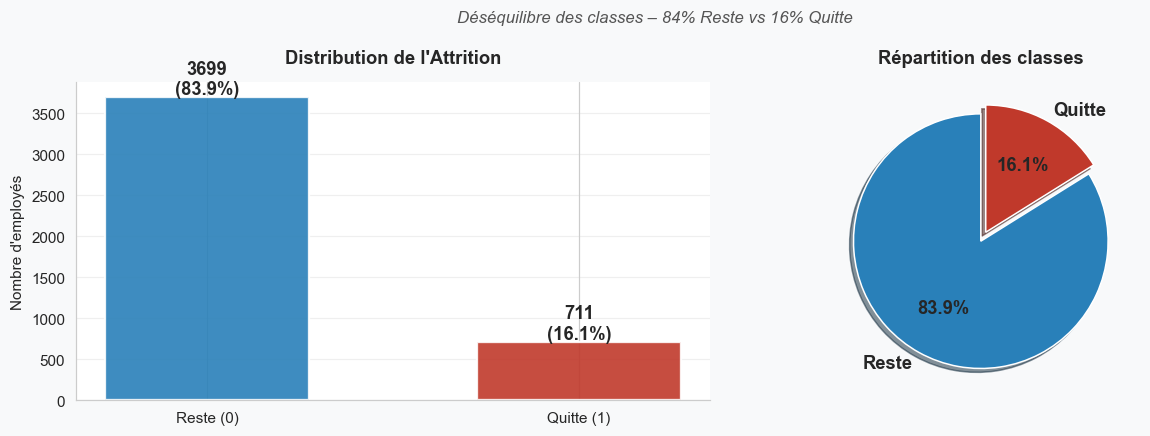

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#f8f9fa')
counts = df['Attrition'].value_counts()
colors_cls = ['#2980b9', '#c0392b']

bars = axes[0].bar(['Reste (0)', 'Quitte (1)'], counts.values,
                    color=colors_cls, edgecolor='white', width=0.55, linewidth=1.5, alpha=0.9)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+30,
                 f'{v}\n({v/len(df):.1%})', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title("Distribution de l'Attrition", fontweight='bold', pad=12)
axes[0].set_ylabel("Nombre d'employés")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(counts.values, labels=['Reste', 'Quitte'], autopct='%1.1f%%',
            colors=colors_cls, startangle=90, explode=(0, 0.08),
            textprops={'fontsize': 12, 'fontweight': 'bold'}, shadow=True)
axes[1].set_title("Répartition des classes", fontweight='bold', pad=12)

plt.suptitle("Déséquilibre des classes – 84% Reste vs 16% Quitte",
             fontsize=11, style='italic', color='#555')
plt.tight_layout()
plt.show()

## 1.2 Taux d'Attrition par Variable Catégorielle

> **Pourquoi ce graphique ?**  
> Pour chaque variable catégorielle (département, niveau de poste, heures supplémentaires…), on veut savoir si certaines **modalités concentrent davantage de départs**. C'est l'analyse bivariée la plus lisible pour des variables nominales ou ordinales.

**Comment il est construit :**
- `df.groupby(col)['Attrition'].mean()` calcule le **taux de départ** (entre 0 et 1) dans chaque sous-groupe
- Tri décroissant : les modalités les plus à risque apparaissent en premier
- Les barres sont **colorées automatiquement** selon des seuils de risque :
  - 🔴 **Rouge** : taux > 20% — sur-représentation significative des départs
  - 🟠 **Orange** : taux 15–20% — risque modéré
  - 🟢 **Vert** : taux < 15% — risque inférieur à la moyenne
- La **ligne pointillée bleue** matérialise le taux global (≈16%) comme référence

**Lecture :** Une barre rouge indique que cette modalité est sur-représentée dans les départs. Par exemple, `OverTime = Yes` affiche typiquement ≈30%, presque le double de la moyenne globale.

**Limite importante :** Cette analyse est **univariée** — elle ne contrôle pas les autres variables. Un fort taux dans un département peut refléter que ce département concentre des juniors mal payés, pas nécessairement un problème spécifique au département lui-même.

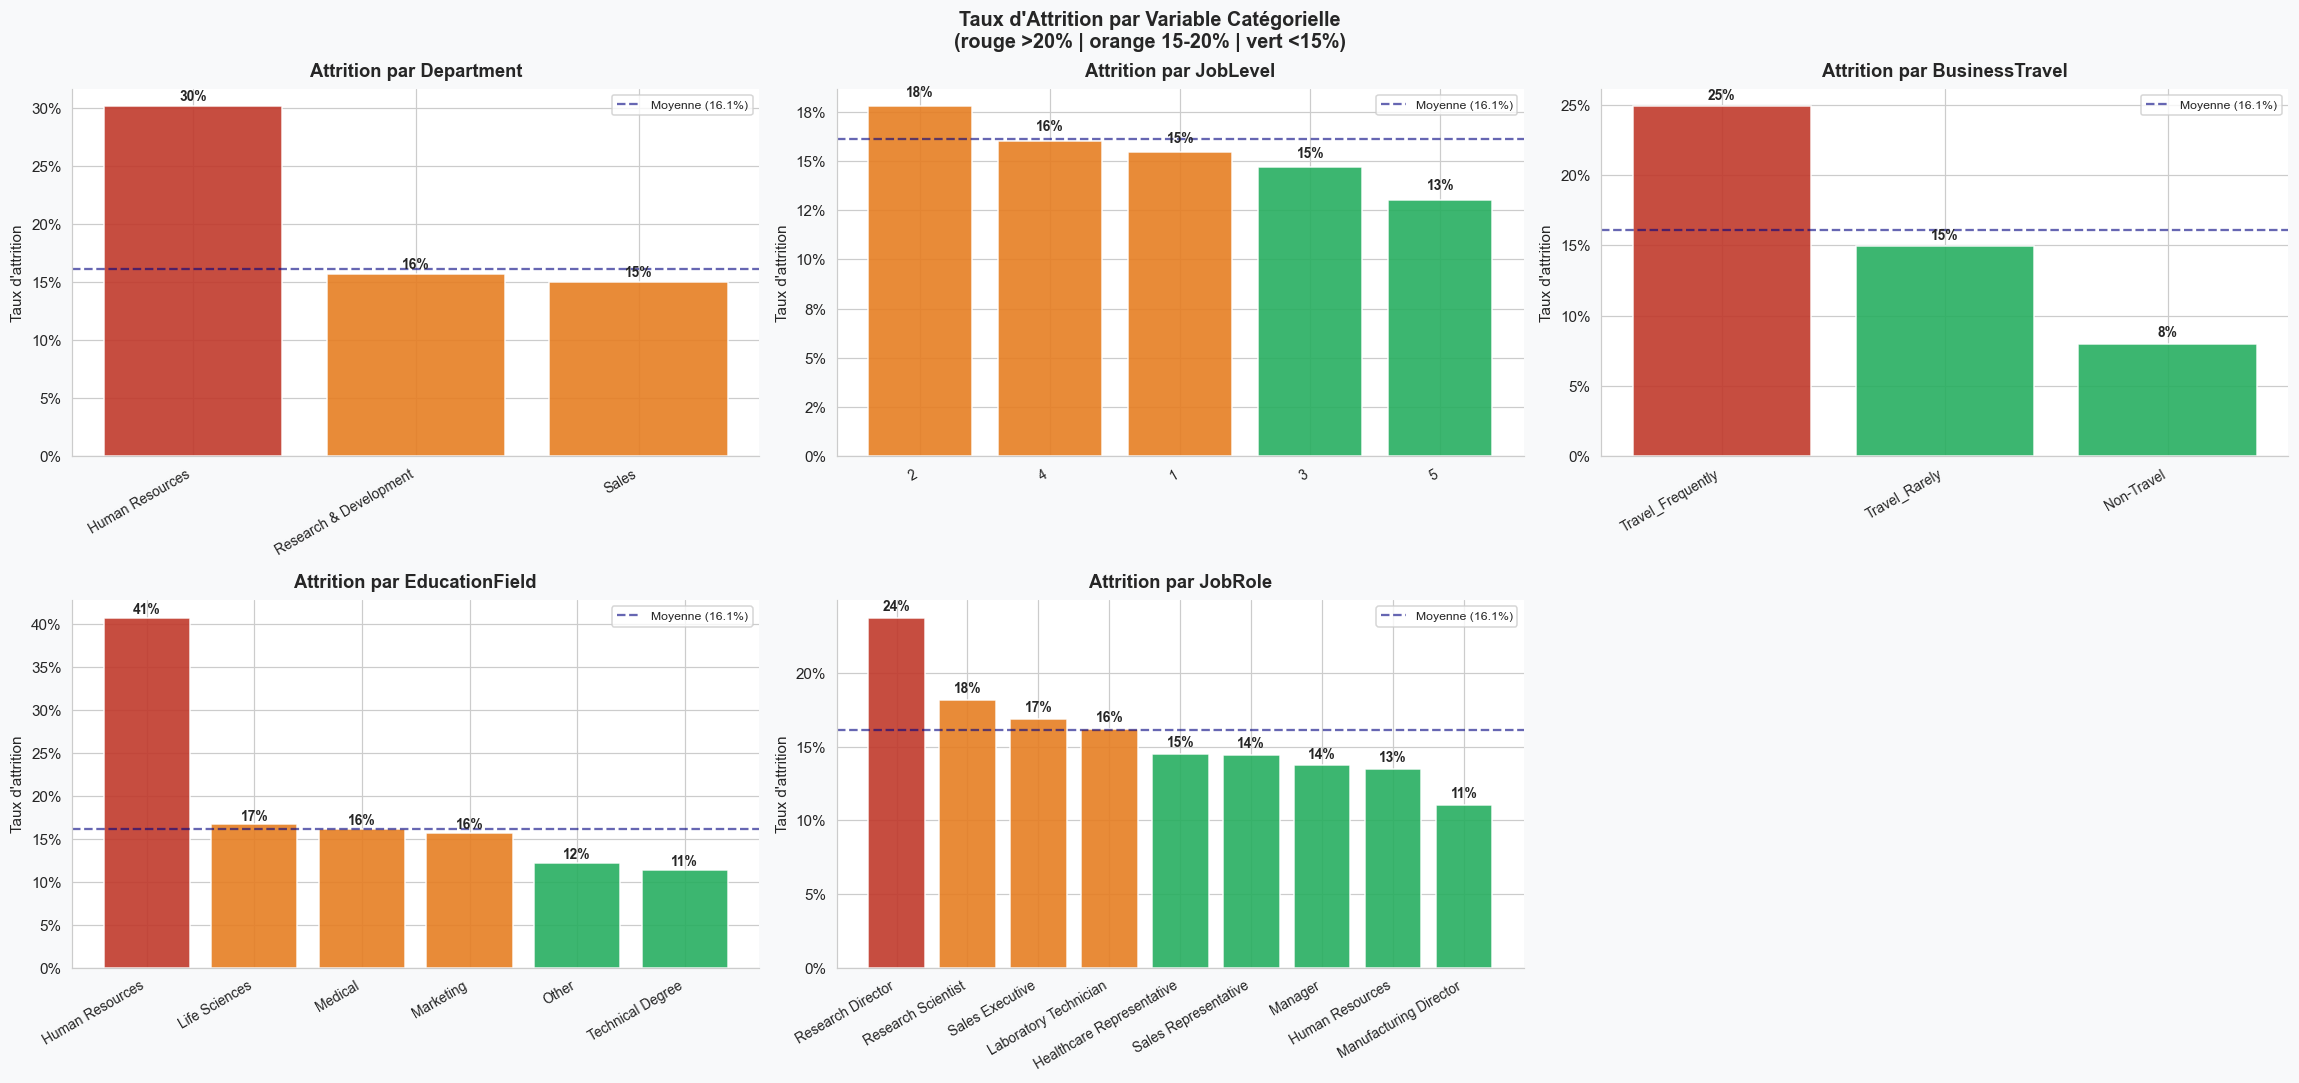

In [7]:
cat_cols = [c for c in ['Department', 'JobLevel', 'OverTime',
                          'BusinessTravel', 'EducationField', 'JobRole']
            if c in df.columns]

n_cols_cat = min(3, len(cat_cols))
n_rows_cat = (len(cat_cols) + n_cols_cat - 1) // n_cols_cat

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(7*n_cols_cat, 5*n_rows_cat))
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten() if len(cat_cols) > 1 else [axes]

global_rate = df['Attrition'].mean()

for i, col in enumerate(cat_cols):
    attr_rate  = df.groupby(col)['Attrition'].mean().sort_values(ascending=False)
    color_bars = ['#c0392b' if v > 0.20 else '#e67e22' if v > 0.15 else '#27ae60'
                  for v in attr_rate.values]
    bars = axes[i].bar(range(len(attr_rate)), attr_rate.values,
                        color=color_bars, edgecolor='white', alpha=0.9)
    axes[i].set_xticks(range(len(attr_rate)))
    axes[i].set_xticklabels(attr_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Attrition par {col}', fontweight='bold', pad=8)
    axes[i].set_ylabel("Taux d'attrition")
    axes[i].axhline(global_rate, color='navy', linestyle='--', alpha=0.6,
                    label=f'Moyenne ({global_rate:.1%})')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    axes[i].legend(fontsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for bar, val in zip(bars, attr_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taux d'Attrition par Variable Catégorielle\n(rouge >20% | orange 15-20% | vert <15%)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.3 Corrélations Point-Biserial – Variables Numériques

> **Pourquoi la corrélation Point-Biserial et pas Pearson ?**  
> La corrélation de Pearson suppose deux variables continues. Ici, `Attrition` est **binaire** (0/1). La **corrélation Point-Biserial** est l'extension naturelle de Pearson pour ce cas — mathématiquement équivalente à Pearson appliqué à une variable dichotomique.

**Formule :**
$$r_{pb} = \frac{\bar{X}_1 - \bar{X}_0}{s_X} \sqrt{\frac{n_1 \cdot n_0}{n^2}}$$

Où $\bar{X}_1$ = moyenne pour les **Quittants** (Attrition=1), $\bar{X}_0$ = moyenne pour les **Restants** (Attrition=0).

**Interprétation des signes — avec Attrition = 1 = Quitte :**
- **Corrélation positive (rouge)** : quand la variable augmente, le risque de départ **augmente** → facteur de risque (ex : `AvgDailyHours` élevé = plus de départs)
- **Corrélation négative (bleu)** : quand la variable augmente, le risque de départ **diminue** → facteur protecteur (ex : `MonthlyIncome` élevé = moins de départs)

**Étoiles de significativité** (test de Student bilatéral sur r) :
- `*` : p < 0.05 → 5% de chance que l'association soit due au hasard
- `**` : p < 0.01 → 1%
- `***` : p < 0.001 → 0.1% — très forte confiance statistique

**Seuils d'interprétation classiques :**
| |r| | Interprétation |
|---|---|
| < 0.10 | Liaison négligeable |
| 0.10 – 0.30 | Liaison faible |
| 0.30 – 0.50 | Liaison modérée |
| > 0.50 | Liaison forte |

**Comment le graphique est construit :**
- `scipy.stats.pointbiserialr(Attrition, variable)` pour chaque feature numérique
- Tri par valeur absolue décroissante — les features les plus discriminantes apparaissent en haut
- Le tableau de style en dessous colore en **rouge les corrélations positives** (risque) et en **bleu les négatives** (protection) via `cmap='RdBu'`

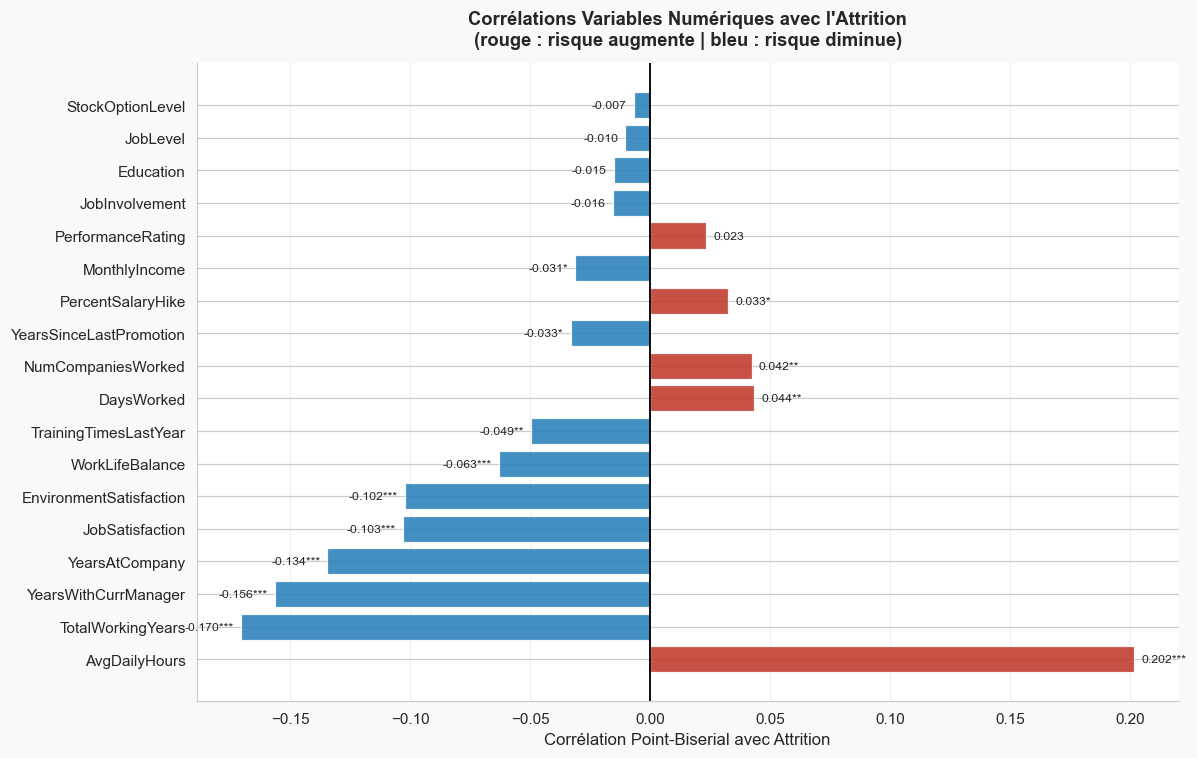

,Variable,Corrélation,p-value
0,AvgDailyHours,0.2017,1.05e-41
1,TotalWorkingYears,-0.1703,5.24e-30
2,YearsWithCurrManager,-0.1562,1.73e-25
3,YearsAtCompany,-0.1344,3.16e-19
4,JobSatisfaction,-0.1028,8.46e-12
5,EnvironmentSatisfaction,-0.1021,1.21e-11
6,WorkLifeBalance,-0.0628,3.29e-05
7,TrainingTimesLastYear,-0.0494,1.02e-03
8,DaysWorked,0.0435,3.85e-03
9,NumCompaniesWorked,0.0423,5.01e-03


In [8]:
num_feats_corr = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Attrition']
corr_list = []
for col in num_feats_corr:
    sub = df[[col, 'Attrition']].dropna()
    if len(sub) > 10 and sub[col].std() > 0:
        corr, pval = stats.pointbiserialr(sub['Attrition'], sub[col])
        corr_list.append({'Variable': col, 'Corrélation': corr, 'p-value': pval})

corr_df = pd.DataFrame(corr_list).sort_values('Corrélation', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f8f9fa')
colors_bar = ['#c0392b' if c > 0 else '#2980b9' for c in corr_df['Corrélation']]
bars = ax.barh(corr_df['Variable'], corr_df['Corrélation'],
               color=colors_bar, edgecolor='white', alpha=0.88, linewidth=0.8)
ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_xlabel('Corrélation Point-Biserial avec Attrition', fontsize=11)
ax.set_title('Corrélations Variables Numériques avec l\'Attrition\n(rouge : risque augmente | bleu : risque diminue)',
             fontweight='bold', pad=12)

for bar, row in zip(bars, corr_df.itertuples()):
    x = bar.get_width()
    sig = '***' if row._3 < 0.001 else '**' if row._3 < 0.01 else '*' if row._3 < 0.05 else ''
    ax.text(x + (0.003 if x > 0 else -0.003), bar.get_y()+bar.get_height()/2,
            f'{x:.3f}{sig}', va='center', ha='left' if x > 0 else 'right', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

display(corr_df.head(10).reset_index(drop=True).style
        .background_gradient(subset=['Corrélation'], cmap='RdBu_r', vmin=-0.4, vmax=0.4)
        .format({'Corrélation': '{:.4f}', 'p-value': '{:.2e}'})
        .set_caption("Top 10 Variables Numériques Corrélées à l'Attrition"))

## 1.4 Heatmap de Corrélation Générale

> **Pourquoi cette heatmap en plus des corrélations Point-Biserial ?**  
> La section 1.3 montrait uniquement la liaison de chaque variable **avec la cible**. Cette heatmap révèle aussi les **corrélations entre features** — cruciales pour deux raisons :
> 1. **Détecter la multicolinéarité** : si deux features ont |r| > 0.8, elles apportent une information redondante. Certains modèles (Régression Logistique) deviennent instables dans ce cas.
> 2. **Comprendre les clusters** : ancienneté, expérience et revenu sont souvent inter-corrélés — cohérent avec la réalité RH.

**Comment ce graphique est construit :**
- `df[cols_num].corr()` calcule la **matrice de corrélation de Pearson** entre toutes les paires
- `mask = np.triu(...)` masque le **triangle supérieur** pour éviter la redondance (matrice symétrique)
- `cmap='RdBu'` avec `center=0` :
  - **Bleu foncé** → corrélation négative forte (proche de -1)
  - **Blanc** → pas de corrélation (0)
  - **Rouge foncé** → corrélation positive forte (proche de +1)
- `annot=True` affiche la valeur numérique dans chaque cellule

**Lecture pratique :**
- La **colonne/ligne `Attrition`** résume les résultats de la section 1.3
- Les **blocs rouges hors diagonale** signalent des features potentiellement redondantes
- `YearsAtCompany`, `TotalWorkingYears`, `YearsWithCurrManager` forment typiquement un cluster cohérent

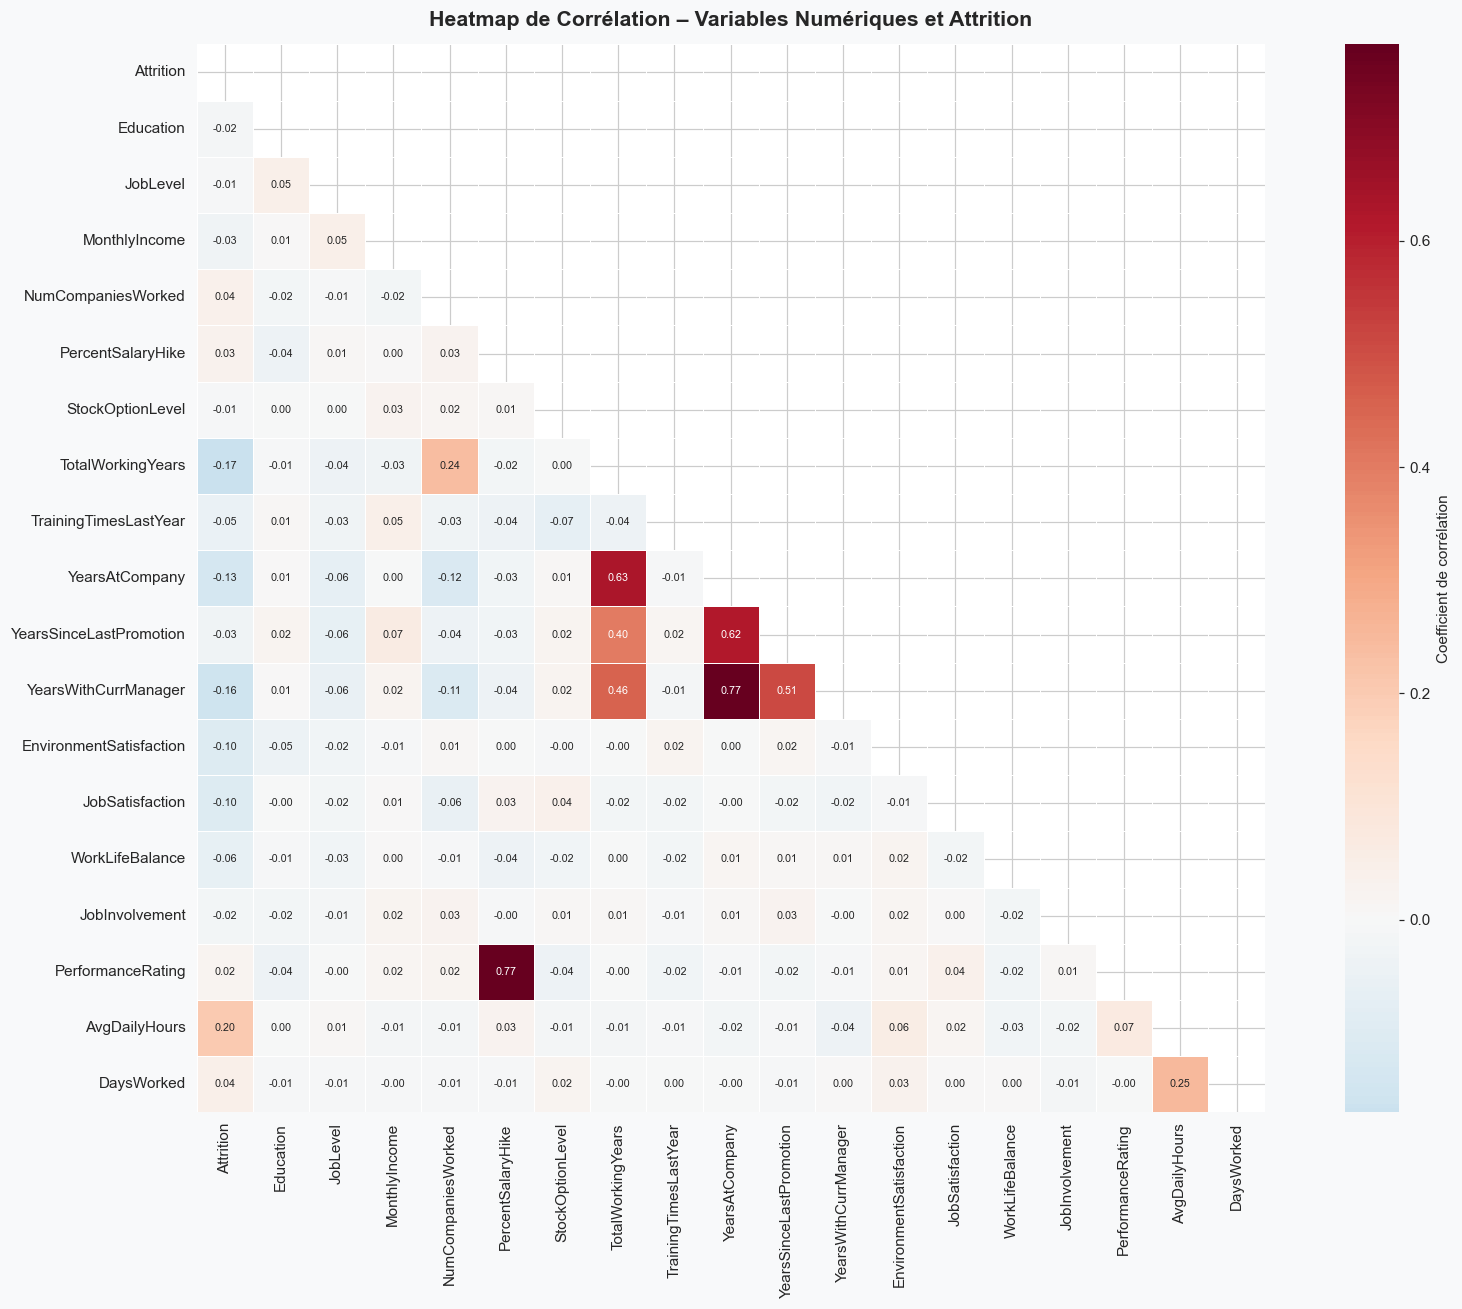

In [9]:
corr_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Coefficient de corrélation'},
    annot_kws={'size': 7}
)
ax.set_title('Heatmap de Corrélation – Variables Numériques et Attrition',
             fontweight='bold', pad=12, fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Boxplots – Variables Numériques par Statut d'Attrition

> **Pourquoi les boxplots en complément des corrélations ?**  
> La corrélation donne un chiffre unique mais ne montre pas **comment** les distributions diffèrent réellement. Les boxplots révèlent des patterns que la corrélation seule peut masquer : distributions asymétriques, bimodales, outliers importants, etc.

**Anatomie d'un boxplot :**
```
     ┌──────────────────────┐
─────┤  Q1          Q3      ├─────  ← moustaches : Q1 - 1.5*IQR  et  Q3 + 1.5*IQR
     └──────────┬───────────┘
               Q2 (médiane)
```
- **Rectangle** : de Q1 à Q3 = IQR, contient 50% des observations
- **Ligne intérieure** = médiane (Q2)
- **Moustaches** = jusqu'à `Q1 - 1.5×IQR` et `Q3 + 1.5×IQR`
- **Points au-delà** = outliers

**Code couleur :** 🔵 Bleu = "Reste" (Attrition=0), 🔴 Rouge = "Quitte" (Attrition=1)

**L'étiquette en abscisse** indique l'écart relatif de moyenne :
$$\text{Ecart} = \frac{\bar{X}_{Quitte} - \bar{X}_{Reste}}{\bar{X}_{Reste}} \times 100\%$$

**Exemple de lecture :** Pour `MonthlyIncome`, si la boîte rouge est globalement plus basse que la boîte bleue, cela confirme que les salaires bas sont associés aux départs — et on voit l'amplitude concrète de l'écart.

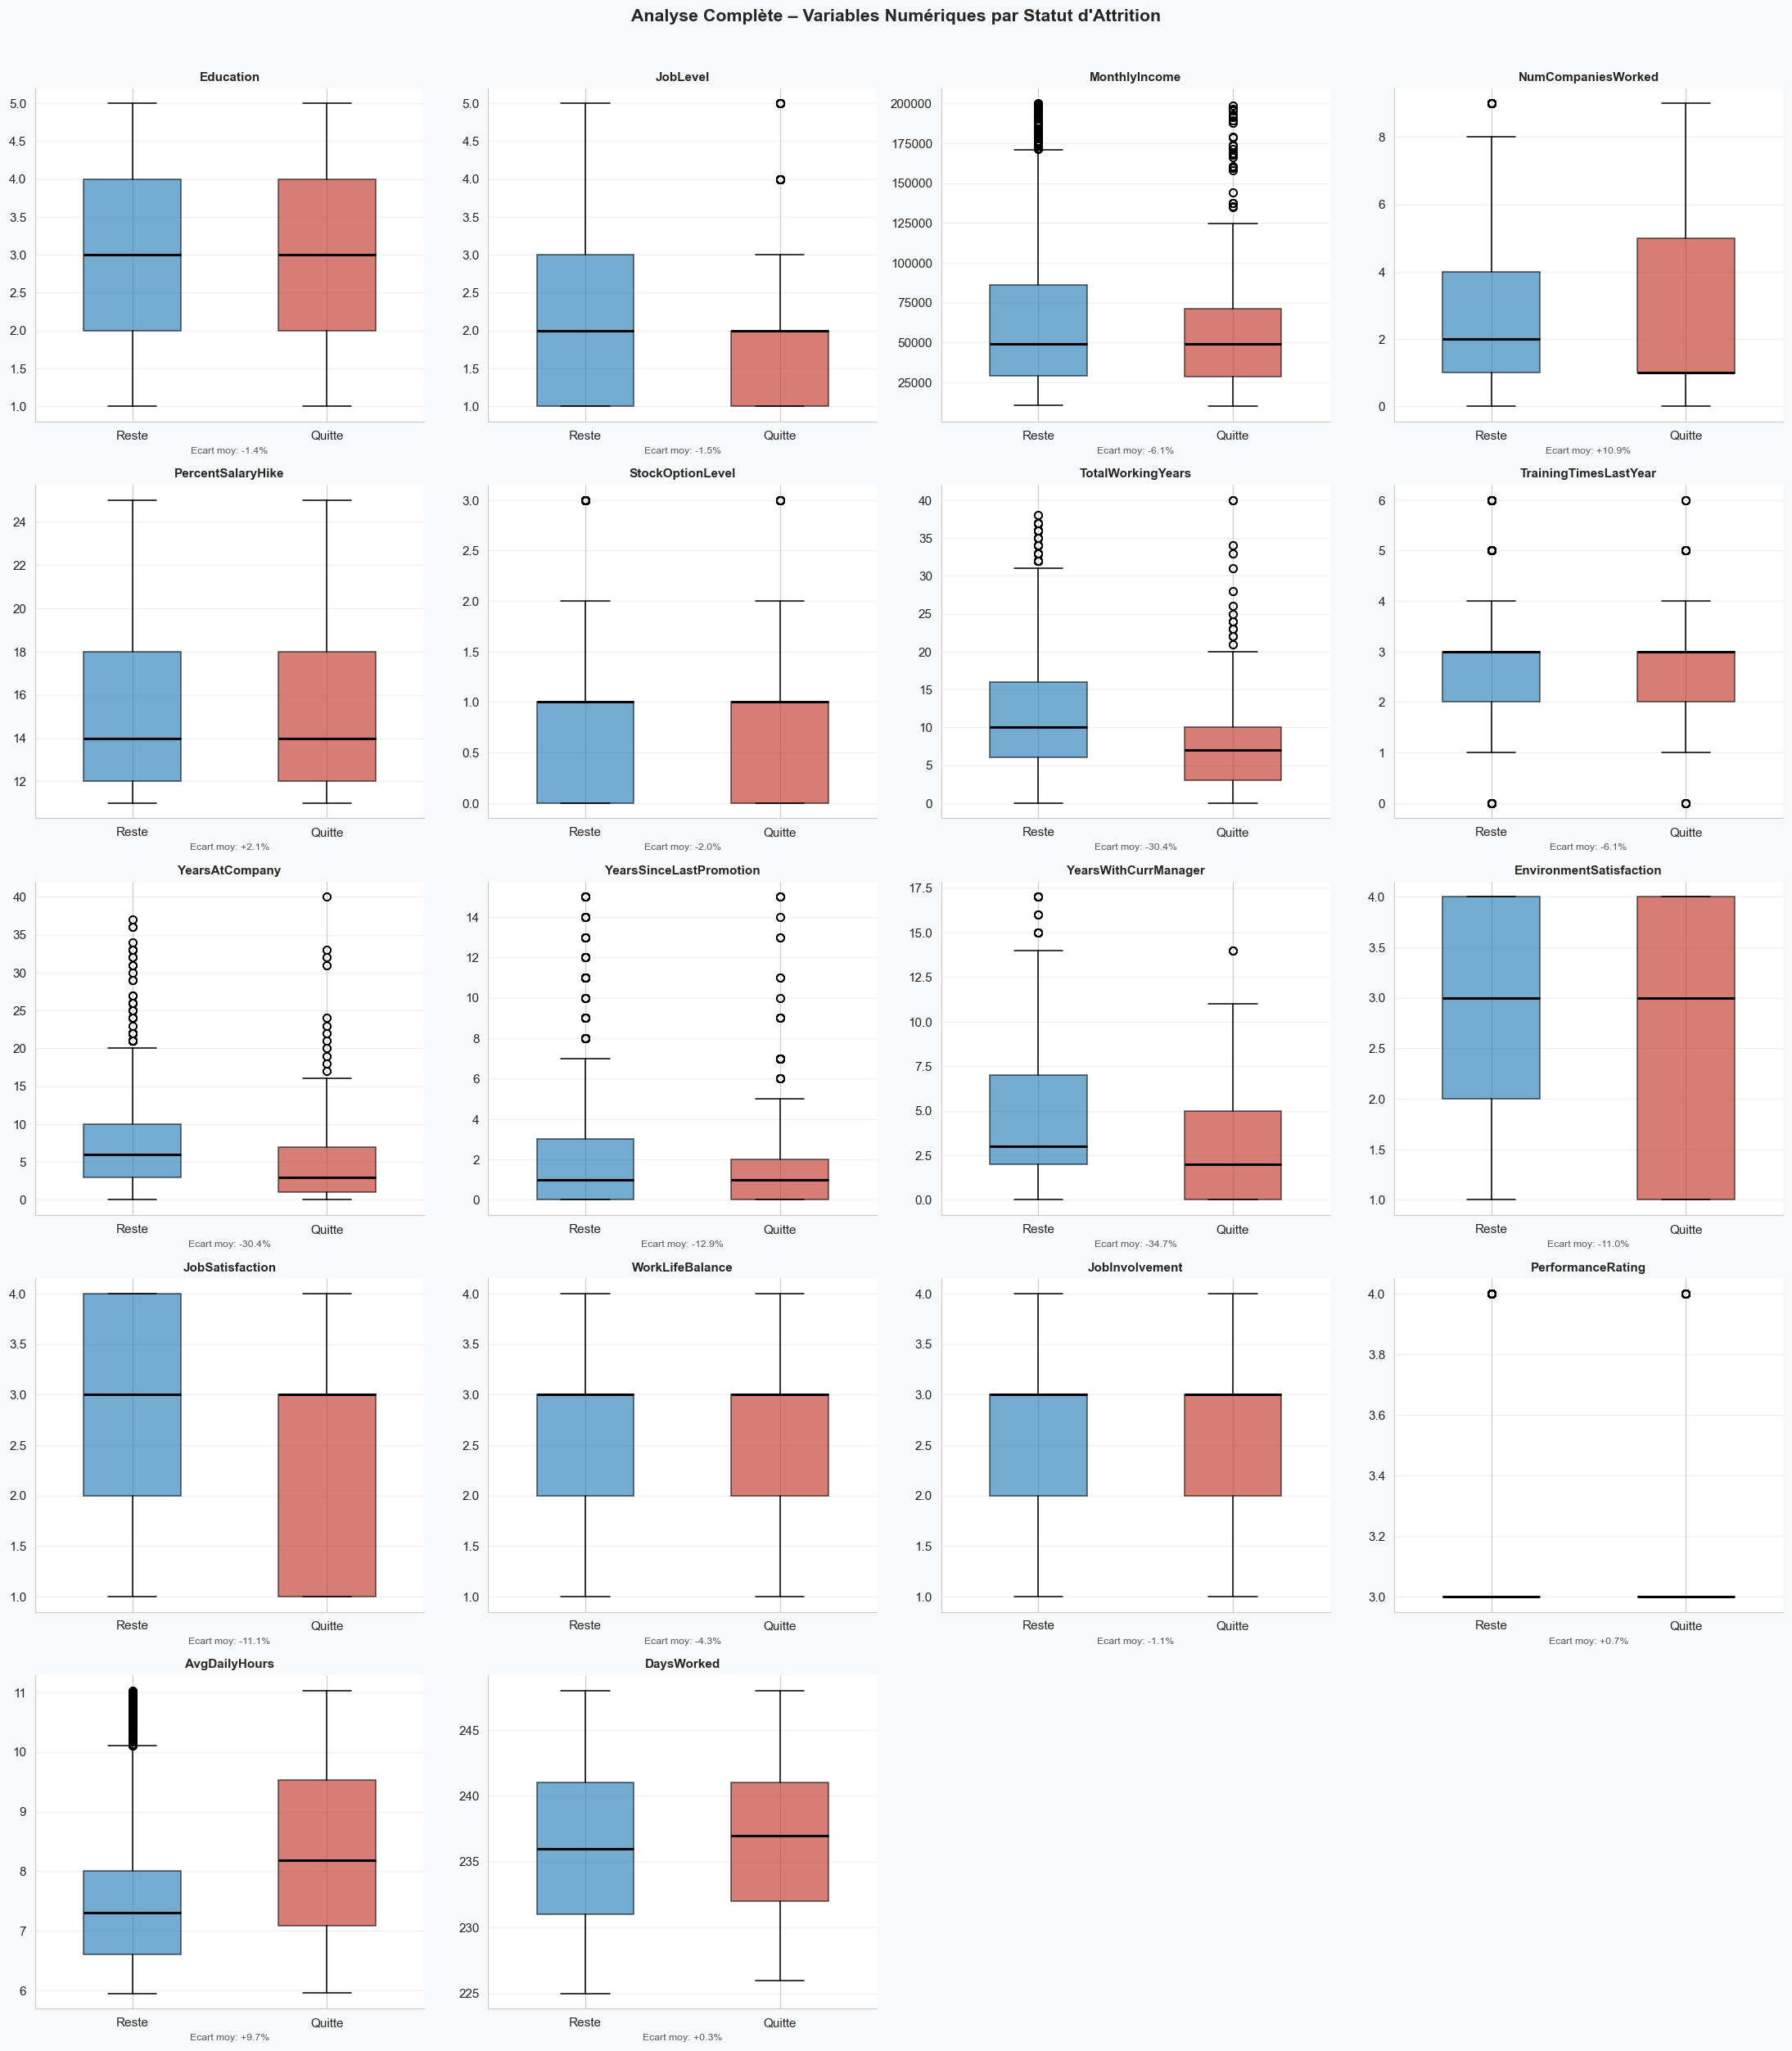

In [10]:
all_num = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Attrition']
n_cols_bp = 4
n_rows_bp = (len(all_num) + n_cols_bp - 1) // n_cols_bp

fig, axes = plt.subplots(n_rows_bp, n_cols_bp, figsize=(20, 4.5 * n_rows_bp))
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()

for idx, col in enumerate(all_num):
    sub   = df[[col, 'Attrition']].dropna()
    stay  = sub[sub['Attrition'] == 0][col]
    leave = sub[sub['Attrition'] == 1][col]
    bp = axes[idx].boxplot([stay, leave], labels=['Reste', 'Quitte'],
                            patch_artist=True, widths=0.5,
                            medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2980b9'); bp['boxes'][0].set_alpha(0.65)
    bp['boxes'][1].set_facecolor('#c0392b'); bp['boxes'][1].set_alpha(0.65)
    axes[idx].set_title(col, fontweight='bold', fontsize=10)
    if stay.mean() != 0:
        diff = (leave.mean() - stay.mean()) / stay.mean() * 100
        axes[idx].set_xlabel(f"Ecart moy: {'+' if diff > 0 else ''}{diff:.1f}%", fontsize=8, color='#555')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Analyse Complète – Variables Numériques par Statut d\'Attrition',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Synthèse EDA – Facteurs Clés d'Attrition

| Catégorie | Variable | Observation |
|---|---|---|
| Catégorielle | `OverTime = Yes` | Taux d'attrition environ 30% contre 10% pour les autres |
| Catégorielle | `BusinessTravel = Frequent` | Fatigue accrue, déséquilibre vie professionnelle / personnelle |
| Catégorielle | `JobLevel 1–2` | Peu de perspectives d'évolution à court terme |
| Numérique | `MonthlyIncome` (faible) | Salaire bas associé à un taux de départ plus élevé |
| Numérique | `YearsAtCompany` (faible) | Les nouvelles recrues partent davantage |
| Numérique | `TotalWorkingYears` (faible) | Moins d'expérience corrélé à un plus fort turnover |
| Numérique | `AvgDailyHours` (élevé) | Surcharge horaire perceptible dans le pointage |

> **Profil à risque type :** Faible revenu · Heures supplémentaires · Employé récent · Déplacements fréquents


---
# PARTIE 2 – Modèles Classiques

## Présentation générale

Cinq algorithmes aux hypothèses mathématiques distinctes constituent les fondations du ML supervisé.
Chacun sert de **référence de comparaison** pour les modèles ensemblistes de la Partie 3.

> **Pourquoi tester plusieurs modèles ?**  
> Il n'existe pas d'algorithme universellement supérieur (No Free Lunch Theorem). Selon la structure des données (linéarité, outliers, interactions, déséquilibre), certains algorithmes performent mieux que d'autres.

### Stratégie d'optimisation commune

| Élément | Choix | Justification |
|---|---|---|
| Optimisation | `GridSearchCV` | Exploration exhaustive de toutes les combinaisons d'hyperparamètres |
| Validation | `StratifiedKFold (k=5)` | Préserve les 16% de positifs dans chaque fold |
| Scoring | `AUC-ROC` | Robuste au déséquilibre, indépendant du seuil de décision |
| Gestion déséquilibre | `class_weight='balanced'` | Pénalise davantage les erreurs sur la classe minoritaire (Quitte) |

**Fonctionnement de la validation croisée 5-fold stratifiée :**
```
Données train (3528)  →  5 découpes :
  Fold 1 : [━━━━━━━━][░░░░░░░░░░░░░░░░░░░░░░░░░]   train=2822 / val=706
  Fold 2 : [░░░░░░░░][━━━━━━━━][░░░░░░░░░░░░░░░░░]   train=2822 / val=706
  ...
→ Score moyen sur 5 folds = estimation robuste de la généralisation
→ Combinaison d'hyperparamètres ayant le meilleur score moyen est retenue
```

### Métriques utilisées

| Métrique | Formule | Priorité |
|---|---|---|
| **Rappel** | VP / (VP + FN) | ⭐⭐⭐ Ne pas manquer un départ |
| **AUC-ROC** | Aire sous la courbe ROC | ⭐⭐⭐ Robuste au déséquilibre |
| **F1-Score** | 2 × Préc × Rappel / (Préc + Rappel) | ⭐⭐ Équilibre global |
| **Précision** | VP / (VP + FP) | ⭐ Ne pas sur-alerter |
| **Accuracy** | (VP + VN) / Total | ⚠️ Trompeuse avec déséquilibre |

In [11]:
c_results = []
c_models  = {}

---
### 2.1 Régression Logistique

**Principe :** Combinaison linéaire pondérée des features transformée par la fonction sigmoïde pour produire une probabilité dans [0, 1].

$$P(\text{Quitte}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

| Hyperparamètre | Rôle |
|---|---|
| `C` élevé | Moins de régularisation — modèle plus complexe |
| `C` faible | Plus de régularisation — meilleure généralisation |
| `L1` (Lasso) | Peut forcer certains coefficients à zéro — sélection implicite de features |
| `L2` (Ridge) | Réduit les coefficients sans les annuler |

**Avantages :** Très interprétable, coefficients signés indiquent la direction de l'effet  
**Limite :** Suppose une relation linéaire entre les features et le log-odds


In [12]:
gs_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_p, y_train)
c_models['Logistic Regression'] = gs_lr.best_estimator_
c_results.append(eval_model('Logistic Regression', gs_lr.best_estimator_,
                             X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'Logistic Regression',
    'AUC-ROC CV (best)': f"{gs_lr.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_lr.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,Logistic Regression,0.7856,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline..."


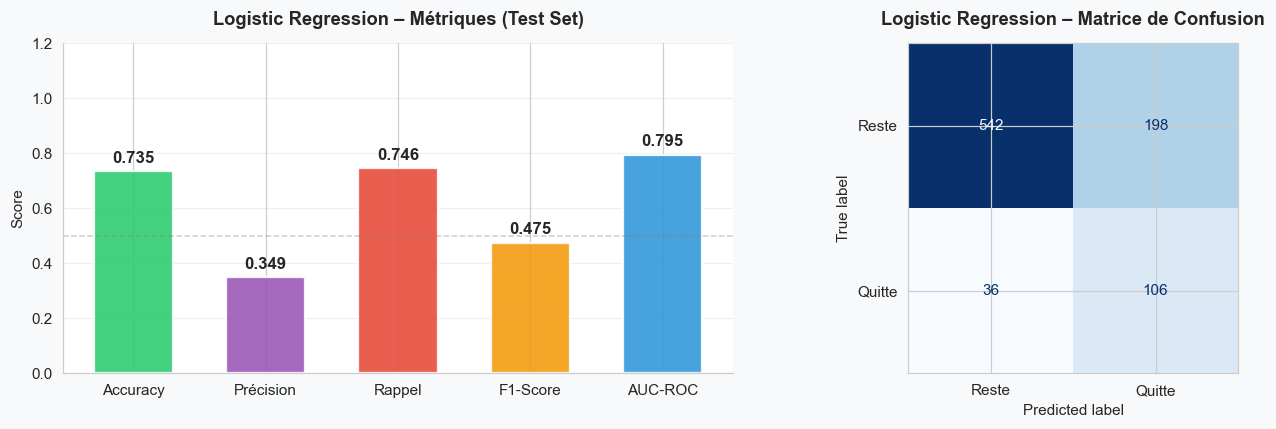

,Précision,Rappel,F1-Score,Support
Reste,0.938,0.732,0.822,740
Quitte,0.349,0.746,0.475,142
macro avg,0.643,0.739,0.649,882
weighted avg,0.843,0.735,0.767,882


In [13]:
_ = show_model_dashboard('Logistic Regression', gs_lr.best_estimator_, X_test_p, y_test)

---
### 2.2 SVM – Support Vector Machine

**Principe :** Recherche de l'hyperplan qui maximise la marge entre les deux classes. Le kernel RBF projette les données dans un espace de dimension supérieure pour traiter les cas non linéairement séparables.

| Hyperparamètre | Rôle |
|---|---|
| `C` | Tolérance aux erreurs de classification — grand C = marge plus étroite |
| `gamma` | Portée d'influence de chaque point d'entraînement |

**Avantages :** Performant en haute dimension, robuste à l'overfitting  
**Limite :** Coût computationnel élevé sur grands datasets, nécessite une standardisation préalable (appliquée)


In [14]:
gs_svm = GridSearchCV(
    SVC(random_state=42, probability=True, class_weight='balanced'),
    {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_svm.fit(X_train_p, y_train)
c_models['SVM'] = gs_svm.best_estimator_
c_results.append(eval_model('SVM', gs_svm.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'SVM',
    'AUC-ROC CV (best)': f"{gs_svm.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_svm.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,SVM,0.9649,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"


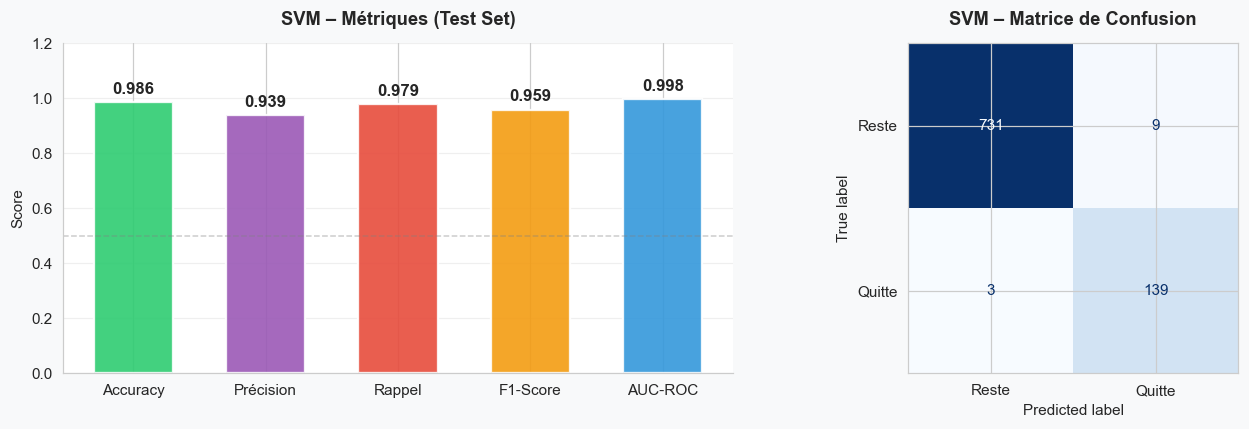

,Précision,Rappel,F1-Score,Support
Reste,0.996,0.988,0.992,740
Quitte,0.939,0.979,0.959,142
macro avg,0.968,0.983,0.975,882
weighted avg,0.987,0.986,0.987,882


In [15]:
_ = show_model_dashboard('SVM', gs_svm.best_estimator_, X_test_p, y_test)

---
### 2.3 KNN – K-Nearest Neighbors

**Principe :** Pour prédire la classe d'un point inconnu, le modèle identifie les K points d'entraînement les plus proches (distance euclidienne ou Manhattan) et vote à la majorité.

| Hyperparamètre | Rôle |
|---|---|
| `n_neighbors (K)` | K faible : sensible au bruit — K élevé : lissage plus fort |
| `weights` | `uniform` : vote égal — `distance` : les voisins proches ont plus de poids |
| `metric` | Distance euclidienne ou Manhattan |

**Avantages :** Non-paramétrique, aucune hypothèse sur la distribution  
**Limite :** Lent à l'inférence, sensible aux outliers et aux features non normalisées (normalisées ici)


In [16]:
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 11, 15, 21], 'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_knn.fit(X_train_p, y_train)
c_models['KNN'] = gs_knn.best_estimator_
c_results.append(eval_model('KNN', gs_knn.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'KNN',
    'AUC-ROC CV (best)': f"{gs_knn.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_knn.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,KNN,0.9692,"{'metric': 'manhattan', 'n_neighbors': 21, 'we..."


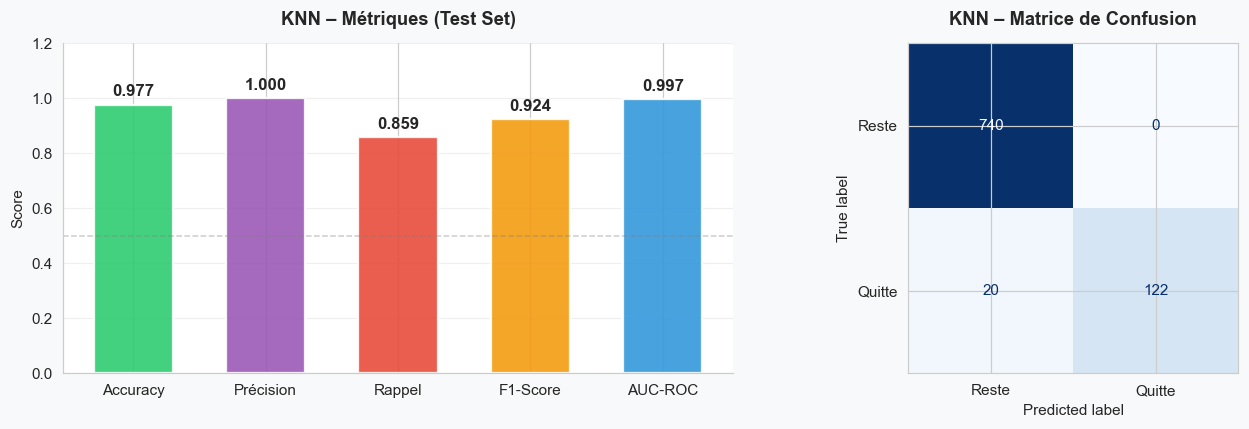

,Précision,Rappel,F1-Score,Support
Reste,0.974,1.000,0.987,740
Quitte,1.000,0.859,0.924,142
macro avg,0.987,0.930,0.955,882
weighted avg,0.978,0.977,0.977,882


In [17]:
_ = show_model_dashboard('KNN', gs_knn.best_estimator_, X_test_p, y_test)

---
### 2.4 Naive Bayes (Gaussien)

**Principe :** Application du théorème de Bayes en supposant que toutes les features sont indépendantes conditionnellement à la classe — hypothèse dite « naïve ». La version gaussienne suppose une distribution normale pour chaque feature.

$$P(\text{Quitte} | X) \propto P(\text{Quitte}) \times \prod_{i} P(x_i | \text{Quitte})$$

**Avantages :** Très rapide, bonne baseline pour les datasets de petite taille  
**Limite :** L'indépendance conditionnelle est rarement vérifiée en pratique (ex : salaire et ancienneté sont corrélés)


In [18]:
gs_nb = GridSearchCV(
    GaussianNB(),
    {'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3]},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_nb.fit(X_train_p, y_train)
c_models['Naive Bayes'] = gs_nb.best_estimator_
c_results.append(eval_model('Naive Bayes', gs_nb.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'Naive Bayes',
    'AUC-ROC CV (best)': f"{gs_nb.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_nb.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,Naive Bayes,0.7128,{'var_smoothing': 0.001}


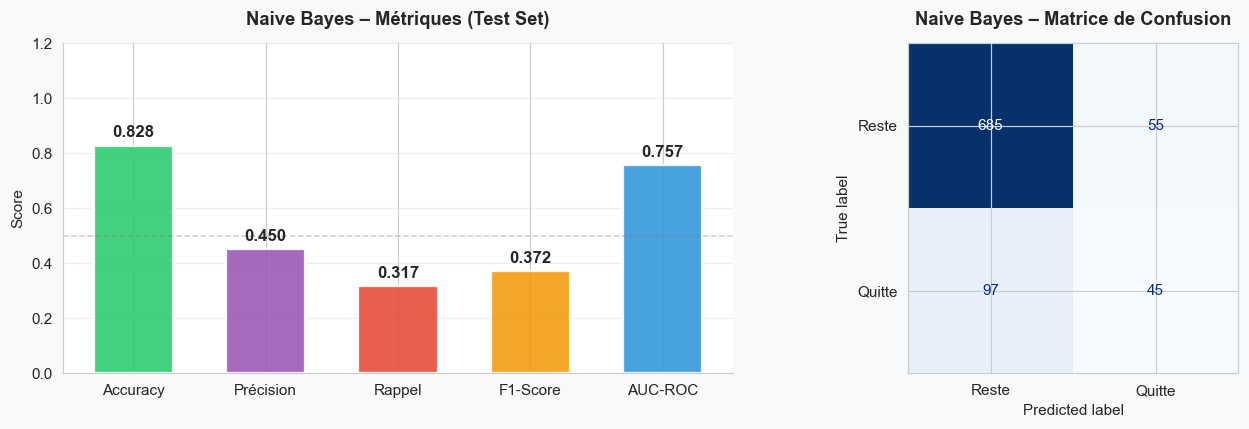

,Précision,Rappel,F1-Score,Support
Reste,0.876,0.926,0.900,740
Quitte,0.450,0.317,0.372,142
macro avg,0.663,0.621,0.636,882
weighted avg,0.807,0.828,0.815,882


In [19]:
_ = show_model_dashboard('Naive Bayes', gs_nb.best_estimator_, X_test_p, y_test)

---
### 2.5 Arbre de Décision

**Principe :** Partitionnement récursif de l'espace des features via des règles binaires, visant à maximiser la pureté des feuilles selon le critère Gini ou l'entropie.

$$Gini = 1 - \sum_{k} p_k^2$$

| Hyperparamètre | Rôle |
|---|---|
| `max_depth` | Profondeur maximale — contrôle l'overfitting |
| `min_samples_split` | Nombre minimum d'observations pour diviser un nœud |
| `min_samples_leaf` | Nombre minimum d'observations dans une feuille terminale |

**Avantages :** Très interprétable, gère nativement les non-linéarités  
**Limite :** Fortement sujet à l'overfitting sans contrainte sur la profondeur — sert de brique de base aux modèles ensemblistes


In [20]:
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_dt.fit(X_train_p, y_train)
c_models['Decision Tree'] = gs_dt.best_estimator_
c_results.append(eval_model('Decision Tree', gs_dt.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'Decision Tree',
    'AUC-ROC CV (best)': f"{gs_dt.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_dt.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,Decision Tree,0.9183,"{'criterion': 'entropy', 'max_depth': None, 'm..."


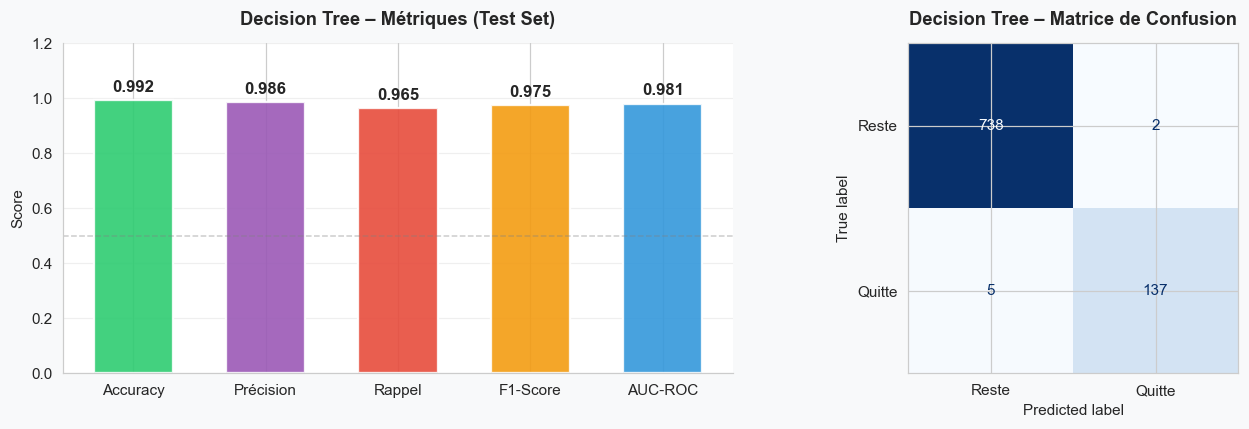

,Précision,Rappel,F1-Score,Support
Reste,0.993,0.997,0.995,740
Quitte,0.986,0.965,0.975,142
macro avg,0.989,0.981,0.985,882
weighted avg,0.992,0.992,0.992,882


In [21]:
_ = show_model_dashboard('Decision Tree', gs_dt.best_estimator_, X_test_p, y_test)

---
## Bilan – Modèles Classiques

> **Comment lire la heatmap de métriques ?**  
> Chaque ligne = un modèle, chaque colonne = une métrique. Le dégradé vert (YlGn) permet de repérer visuellement les meilleures cellules. **Attention :** une Accuracy élevée n'est pas un bon signal ici — ce qui compte, c'est le Rappel et l'AUC-ROC.

> **Comment lire les courbes ROC ?**  
> La courbe ROC trace le Rappel (Taux de Vrais Positifs, TPR) vs le Taux de Faux Positifs (FPR) pour tous les seuils de décision de 0 à 1.  
> - **Coin supérieur gauche** = modèle parfait (haute sensibilité, peu de fausses alertes)
> - **Diagonale pointillée** = modèle aléatoire (AUC=0.5) = référence plancher  
> - **AUC** = résume la courbe en un seul chiffre : 1.0 = parfait, 0.5 = aléatoire

> **Overfitting :** Si la courbe train est parfaite mais s'effondre sur le test, le modèle a mémorisé les données sans généraliser. On le détecte en comparant les métriques train vs test dans `eval_model`.

,Accuracy,Précision,Rappel,F1-Score,AUC-ROC
model,,,,,
Logistic Regression,0.7347,0.3487,0.7465,0.4753,0.7952
SVM,0.9864,0.9392,0.9789,0.9586,0.9979
KNN,0.9773,1.0000,0.8592,0.9242,0.9974
Naive Bayes,0.8277,0.4500,0.3169,0.3719,0.7571
Decision Tree,0.9921,0.9856,0.9648,0.9751,0.9810


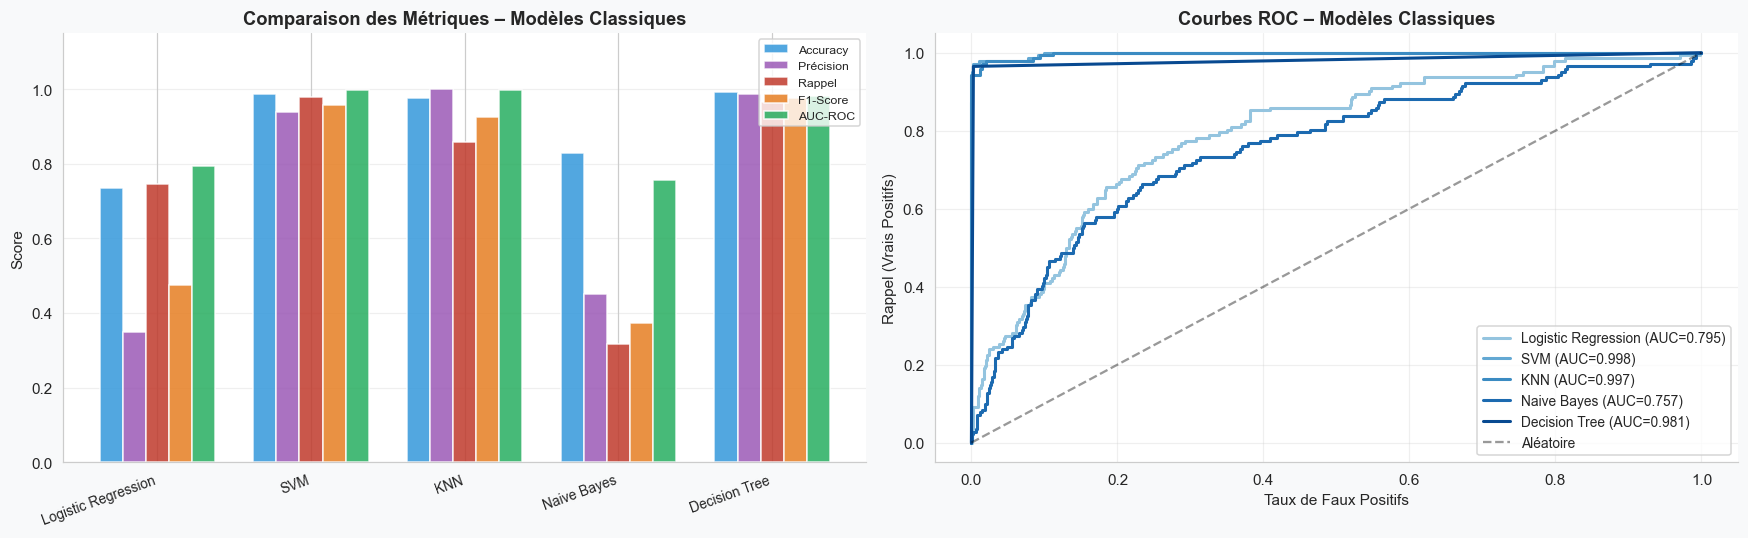

In [22]:
df_classic = pd.DataFrame(c_results).set_index('model')
metrics_list = ['test_acc', 'test_prec', 'test_rec', 'test_f1', 'test_auc']
labels_m     = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'AUC-ROC']

display(df_classic[metrics_list].rename(columns=dict(zip(metrics_list, labels_m)))
        .style.background_gradient(cmap='YlGn', axis=0)
        .format('{:.4f}')
        .set_caption("Métriques – Modèles Classiques (Test Set)"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#f8f9fa')

models_c = df_classic.index.tolist()
x = np.arange(len(models_c))
width = 0.15
colors_m = ['#3498db', '#9b59b6', '#c0392b', '#e67e22', '#27ae60']

for i, (m, l, c) in enumerate(zip(metrics_list, labels_m, colors_m)):
    vals = [df_classic.loc[mod, m] if not pd.isna(df_classic.loc[mod, m]) else 0
            for mod in models_c]
    axes[0].bar(x + (i - 2)*width, vals, width, label=l, color=c, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_c, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Comparaison des Métriques – Modèles Classiques', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

colors_roc = plt.cm.Blues(np.linspace(0.4, 0.9, len(c_models)))
for (name, mdl), color in zip(c_models.items(), colors_roc):
    if hasattr(mdl, 'predict_proba'):
        yprob = mdl.predict_proba(X_test_p)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, yprob)
        auc = roc_auc_score(y_test, yprob)
        axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2, color=color)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Rappel (Vrais Positifs)')
axes[1].set_title('Courbes ROC – Modèles Classiques', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
# PARTIE 3 – Modèles Ensemblistes

## Présentation générale

Les modèles ensemblistes combinent plusieurs apprenants de base pour produire un résultat plus robuste et précis qu'un modèle unique.

| Famille | Principe | Avantage principal |
|---|---|---|
| **Bagging** | Modèles entraînés en **parallèle** sur des sous-échantillons, puis agrégation | Réduit la variance (overfitting) |
| **Boosting** | Modèles entraînés en **séquence**, chacun corrigeant les erreurs du précédent | Réduit le biais (underfitting) |
| **Stacking** | Un méta-modèle apprend à combiner les prédictions des bases | Capture les forces complémentaires |

### Avantages clés par rapport aux modèles classiques

- **Réduction de variance** par agrégation — les erreurs individuelles sont décorrélées et se compensent
- **Non-linéarités natives** — pas besoin de feature engineering manuel pour capturer les interactions
- **Feature Importance fiable** — citant la même variable à travers des centaines d'arbres différents, l'importance reflète une influence réelle et non un artefact

> **Intuition du bagging :** Imaginez 500 experts qui chacun voient une partie des données. Certains se trompent, mais leurs erreurs sont aléatoires et indépendantes → la moyenne de leurs décisions est bien meilleure qu'un seul expert.

In [23]:
e_results = []
e_models  = {}

---
## 3.1 Extra Trees – Extremely Randomized Trees (Bagging)

**Principe :** Similaire au Random Forest, avec un degré d'aléatoire supplémentaire : les seuils de division ne sont pas optimisés mais **choisis aléatoirement** parmi un ensemble de candidats. Le meilleur seuil parmi ces candidats aléatoires est retenu.

| Critère | Random Forest | Extra Trees |
|---|---|---|
| Seuil de split | Optimal sur un sous-ensemble de features | Aléatoire parmi des candidats |
| Variance | Faible | Encore plus faible |
| Biais | Standard | Légèrement plus élevé |
| Vitesse d'entraînement | Standard | Plus rapide |

**Avantages :** Réduction supplémentaire de l'overfitting, entraînement accéléré  
**Limite :** Les seuils sous-optimaux peuvent légèrement réduire la précision sur certains datasets


In [24]:
gs_et = GridSearchCV(
    ExtraTreesClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, None],
     'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_et.fit(X_train_p, y_train)
e_models['Extra Trees'] = gs_et.best_estimator_
e_results.append(eval_model('Extra Trees', gs_et.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'Extra Trees',
    'AUC-ROC CV (best)': f"{gs_et.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_et.best_params_)
}]))

/Users/matheo.pinget/Library/CloudStorage/OneDrive-AssociationCesiViacesimail/Documents/CESI/Annee4/IA/Projet/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/matheo.pinget/Library/CloudStorage/OneDrive-AssociationCesiViacesimail/Documents/CESI/Annee4/IA/Projet/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/matheo.pinget/Library/CloudStorage/OneDrive-AssociationCesiViacesimail/Documents/CESI/Annee4/IA/Projet/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklear

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,Extra Trees,0.9955,"{'max_depth': None, 'max_features': 'sqrt', 'm..."


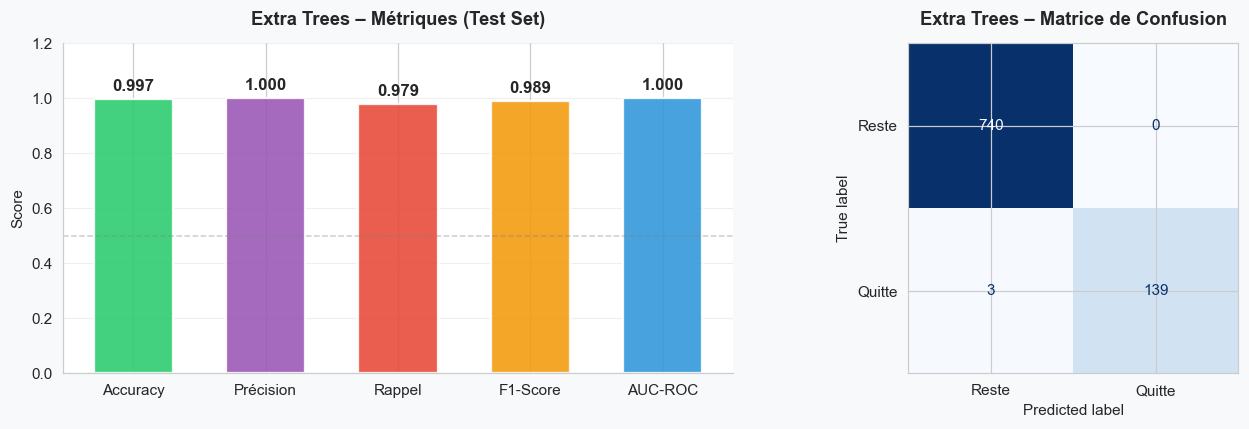

,Précision,Rappel,F1-Score,Support
Reste,0.996,1.000,0.998,740
Quitte,1.000,0.979,0.989,142
macro avg,0.998,0.989,0.994,882
weighted avg,0.997,0.997,0.997,882


In [25]:
_ = show_model_dashboard('Extra Trees', gs_et.best_estimator_, X_test_p, y_test)

---
## 3.2 Gradient Boosting (Boosting)

**Principe :** Les arbres sont construits séquentiellement. Chaque nouvel arbre corrige les erreurs résiduelles (le gradient de la fonction de perte) de l'ensemble précédent.

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Où $\eta$ est le **learning rate** et $h_m$ l'arbre m ajusté sur les résidus de l'étape précédente.

| Hyperparamètre | Rôle |
|---|---|
| `n_estimators` | Nombre d'arbres en séquence |
| `learning_rate` | Contribution de chaque arbre — faible valeur = convergence plus stable |
| `max_depth` | Profondeur de chaque arbre faible (3–5 recommandé) |
| `subsample` | Proportion du dataset utilisée par arbre — valeur < 1 réduit l'overfitting |

**Avantages :** Parmi les modèles les plus performants, capture les interactions complexes entre variables  
**Limite :** Plus lent à entraîner, sensible aux hyperparamètres, risque d'overfitting si le learning rate est trop élevé


In [26]:
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2],
     'max_depth': [3, 5, 7], 'subsample': [0.8, 1.0]},
    cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_gb.fit(X_train_p, y_train)
e_models['Gradient Boosting'] = gs_gb.best_estimator_
e_results.append(eval_model('Gradient Boosting', gs_gb.best_estimator_,
                              X_train_p, y_train, X_test_p, y_test))

display(pd.DataFrame([{
    'Modèle': 'Gradient Boosting',
    'AUC-ROC CV (best)': f"{gs_gb.best_score_:.4f}",
    'Meilleurs paramètres': str(gs_gb.best_params_)
}]))

,Modèle,AUC-ROC CV (best),Meilleurs paramètres
0,Gradient Boosting,0.9850,"{'learning_rate': 0.2, 'max_depth': 7, 'n_esti..."


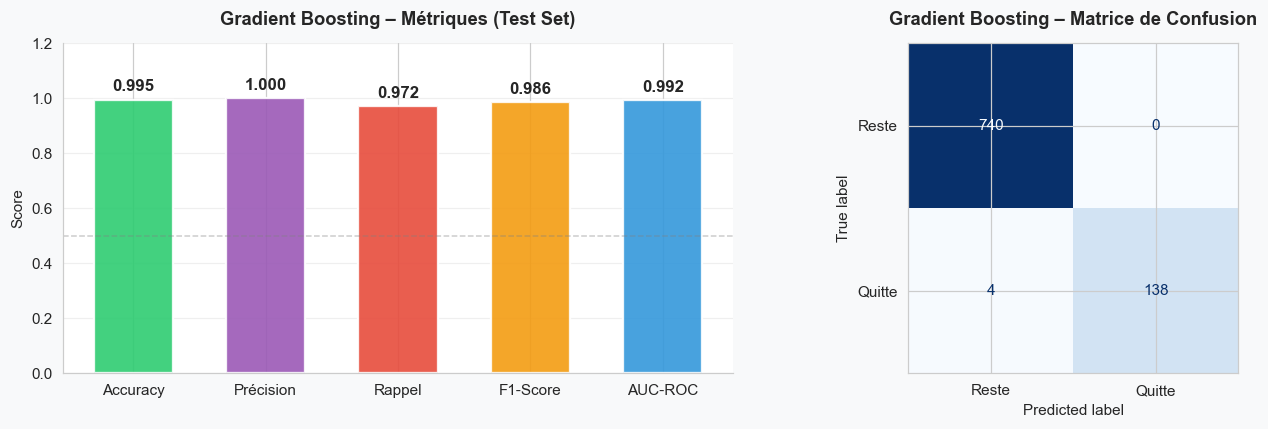

,Précision,Rappel,F1-Score,Support
Reste,0.995,1.000,0.997,740
Quitte,1.000,0.972,0.986,142
macro avg,0.997,0.986,0.992,882
weighted avg,0.995,0.995,0.995,882


In [27]:
_ = show_model_dashboard('Gradient Boosting', gs_gb.best_estimator_, X_test_p, y_test)

---
## 3.3 Stacking Classifier (Méta-apprentissage)

**Principe :** Un méta-modèle (ici une Régression Logistique) est entraîné sur les prédictions produites par trois modèles de base. Il apprend à combiner de façon optimale leurs forces respectives.

```
Niveau 0 – Modèles de base (base learners) :
    ├── Logistic Regression   → prédiction_lr
    ├── SVM                   → prédiction_svm
    └── Decision Tree         → prédiction_dt
              |
              v
Niveau 1 – Méta-modèle :
    Logistic Regression ([pred_lr, pred_svm, pred_dt]) --> prédiction finale
```

**Choix des trois modèles de base :**
- Logistic Regression : modèle linéaire capturant les tendances globales
- SVM : frontières non linéaires capturant les structures complexes
- Decision Tree : règles discrètes, complémentaire aux deux précédents

**Avantages :** Tire parti des forces complémentaires de chaque modèle  
**Limite :** Entraînement plus long, risque de surapprentissage si les modèles de base sont trop similaires


In [28]:
stacking_estimators = [
    ('lr',  gs_lr.best_estimator_),
    ('svm', gs_svm.best_estimator_),
    ('dt',  gs_dt.best_estimator_),
]
stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False
)
stacking.fit(X_train_p, y_train)
e_models['Stacking'] = stacking
e_results.append(eval_model('Stacking', stacking, X_train_p, y_train, X_test_p, y_test))

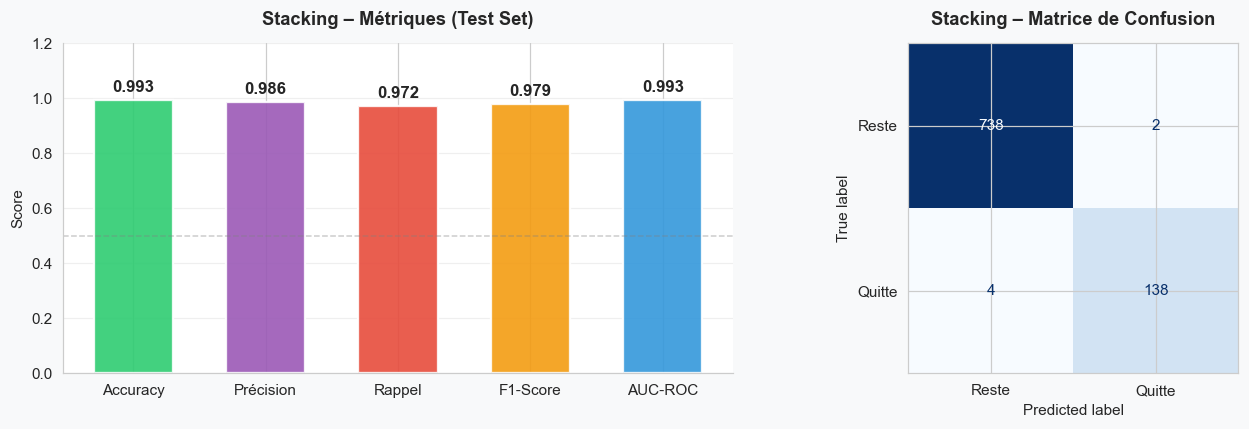

,Précision,Rappel,F1-Score,Support
Reste,0.995,0.997,0.996,740
Quitte,0.986,0.972,0.979,142
macro avg,0.990,0.985,0.987,882
weighted avg,0.993,0.993,0.993,882


In [29]:
_ = show_model_dashboard('Stacking', stacking, X_test_p, y_test)

---
## Bilan – Modèles Ensemblistes

> **Pourquoi les ensemblistes sont-ils généralement meilleurs ?**  
> Un modèle unique est limité par ses hypothèses. Les ensemblistes combinent des dizaines voire centaines d'apprenants faibles :
> - **Extra Trees/Bagging** : chaque arbre voit des données différentes → erreurs décorrélées → la moyenne les annule partiellement
> - **Gradient Boosting** : chaque arbre corrige les erreurs du précédent → convergence progressive vers l'optimum
> - **Stacking** : le méta-modèle apprend *comment* combiner les prédictions, exploitant les forces complémentaires

> **Feature Importance dans les arbres vs corrélation :**  
> La corrélation mesure une liaison **linéaire bivariée**. L'importance dans les arbres capture les **interactions non-linéaires** et les **effets conditionnels** (ex : `OverTime=Yes` AND `JobLevel=1` → risque très élevé). C'est pourquoi elle est plus fiable pour identifier les leviers réels dans des systèmes complexes.

,Accuracy,Précision,Rappel,F1-Score,AUC-ROC
model,,,,,
Extra Trees,0.9966,1.0000,0.9789,0.9893,0.9995
Gradient Boosting,0.9955,1.0000,0.9718,0.9857,0.9921
Stacking,0.9932,0.9857,0.9718,0.9787,0.9934


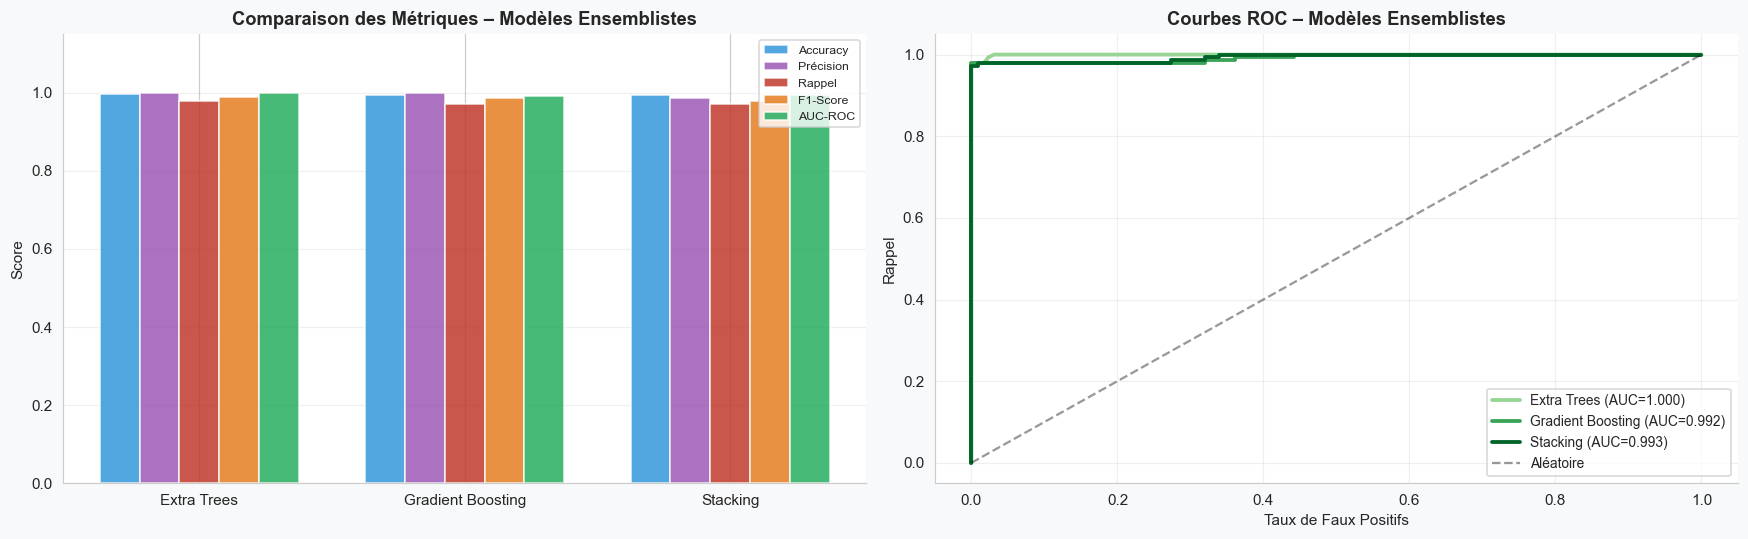

In [30]:
df_ensemble = pd.DataFrame(e_results).set_index('model')

display(df_ensemble[metrics_list].rename(columns=dict(zip(metrics_list, labels_m)))
        .style.background_gradient(cmap='YlGn', axis=0)
        .format('{:.4f}')
        .set_caption("Métriques – Modèles Ensemblistes (Test Set)"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#f8f9fa')

models_e = df_ensemble.index.tolist()
x_e = np.arange(len(models_e))

for i, (m, l, c) in enumerate(zip(metrics_list, labels_m, colors_m)):
    vals = [df_ensemble.loc[mod, m] if not pd.isna(df_ensemble.loc[mod, m]) else 0
            for mod in models_e]
    axes[0].bar(x_e + (i - 2)*width, vals, width, label=l, color=c, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x_e)
axes[0].set_xticklabels(models_e, fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Comparaison des Métriques – Modèles Ensemblistes', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

colors_roc_e = plt.cm.Greens(np.linspace(0.4, 0.9, len(e_models)))
for (name, mdl), color in zip(e_models.items(), colors_roc_e):
    if hasattr(mdl, 'predict_proba'):
        yprob = mdl.predict_proba(X_test_p)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, yprob)
        auc = roc_auc_score(y_test, yprob)
        axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2.5, color=color)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Rappel')
axes[1].set_title('Courbes ROC – Modèles Ensemblistes', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
# PARTIE 4 – Comparaison Globale et Sélection du Modèle Retenu

## Démarche d'amélioration progressive

```
Étape 1 : Baseline interprétable      → Logistic Regression
     |
Étape 2 : Modèles plus complexes      → SVM, KNN, Naive Bayes, Decision Tree
     |
Étape 3 : Optimisation systématique   → GridSearchCV, 5-fold stratifié, AUC-ROC
     |
Étape 4 : Gestion du déséquilibre     → class_weight='balanced'
     |
Étape 5 : Modèles ensemblistes        → Extra Trees, Gradient Boosting, Stacking
     |
Étape 6 : Évaluation multi-métriques  → AUC-ROC, Rappel, F1, Précision, Accuracy
     |
Étape 7 : Score composite pondéré     → Sélection du modèle champion
```

## 4.1 Heatmap Globale et Courbes ROC Comparatives

**Pourquoi la heatmap globale ?**  
Comparer 8 modèles sur 5 métriques en un seul coup d'œil. La ligne noire sépare visuellement modèles classiques et ensemblistes pour évaluer le gain apporté par la complexité.

**Pourquoi la courbe ROC globale ?**  
Chaque point de la courbe ROC correspond à un seuil de décision différent. En contexte RH :
- Seuil bas → **rappel maximal** mais plus de fausses alertes (privilégier si le coût d'un départ non détecté est très élevé)
- Seuil haut → **alertes précises** mais risque de manquer des départs (privilégier si les ressources RH sont limitées)

La courbe ROC permet de **choisir le seuil opérationnel** selon la politique RH de l'entreprise, indépendamment du modèle lui-même.

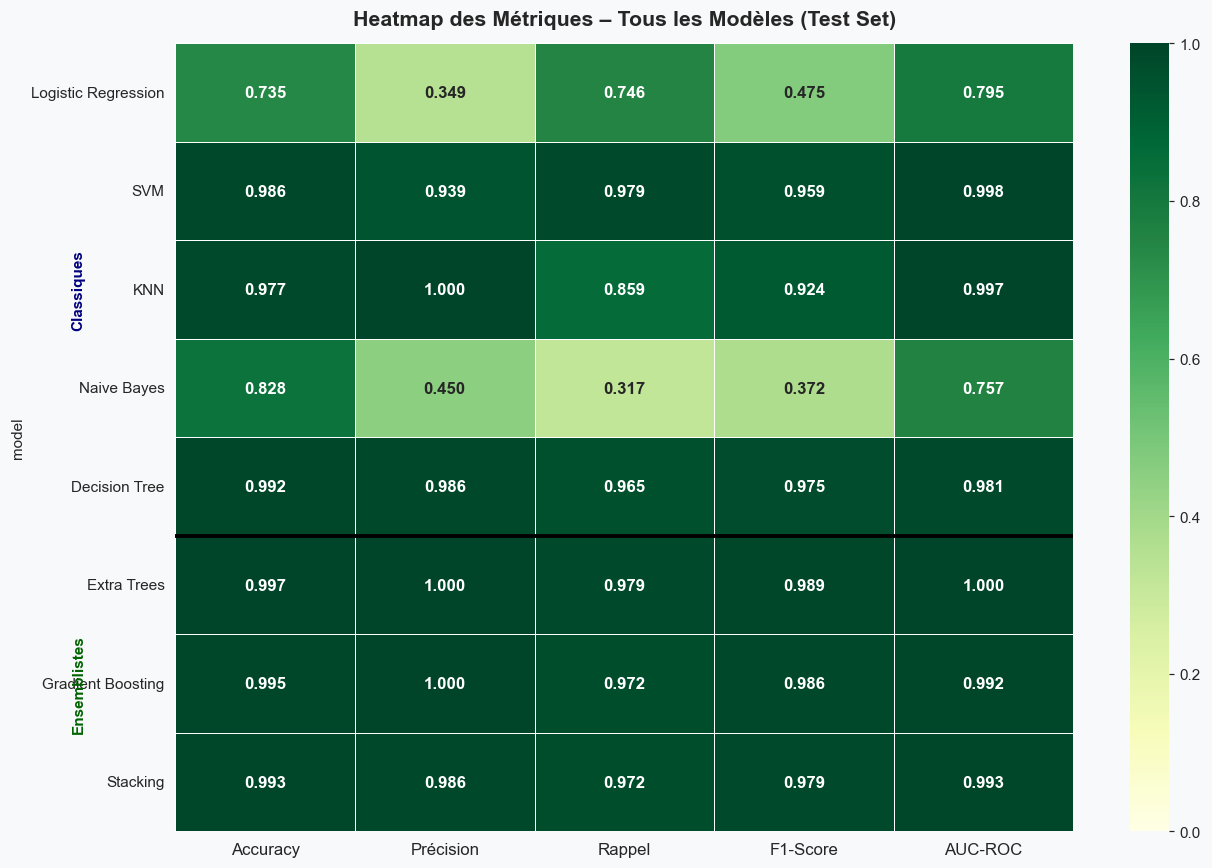

In [31]:
all_results     = c_results + e_results
df_all          = pd.DataFrame(all_results).set_index('model')
all_models_dict = {**c_models, **e_models}

hmd = df_all[metrics_list].fillna(0).copy()
hmd.columns = labels_m

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#f8f9fa')
sns.heatmap(hmd, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.6, ax=ax, annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Heatmap des Métriques – Tous les Modèles (Test Set)',
             fontweight='bold', fontsize=14, pad=12)
ax.set_xticklabels(labels_m, rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.axhline(y=len(c_results), color='black', linewidth=2.5)
ax.text(-0.5, len(c_results)/2, 'Classiques', va='center', ha='right',
        fontsize=10, fontweight='bold', color='navy', rotation=90)
ax.text(-0.5, len(c_results) + len(e_results)/2, 'Ensemblistes', va='center', ha='right',
        fontsize=10, fontweight='bold', color='darkgreen', rotation=90)
plt.tight_layout()
plt.show()

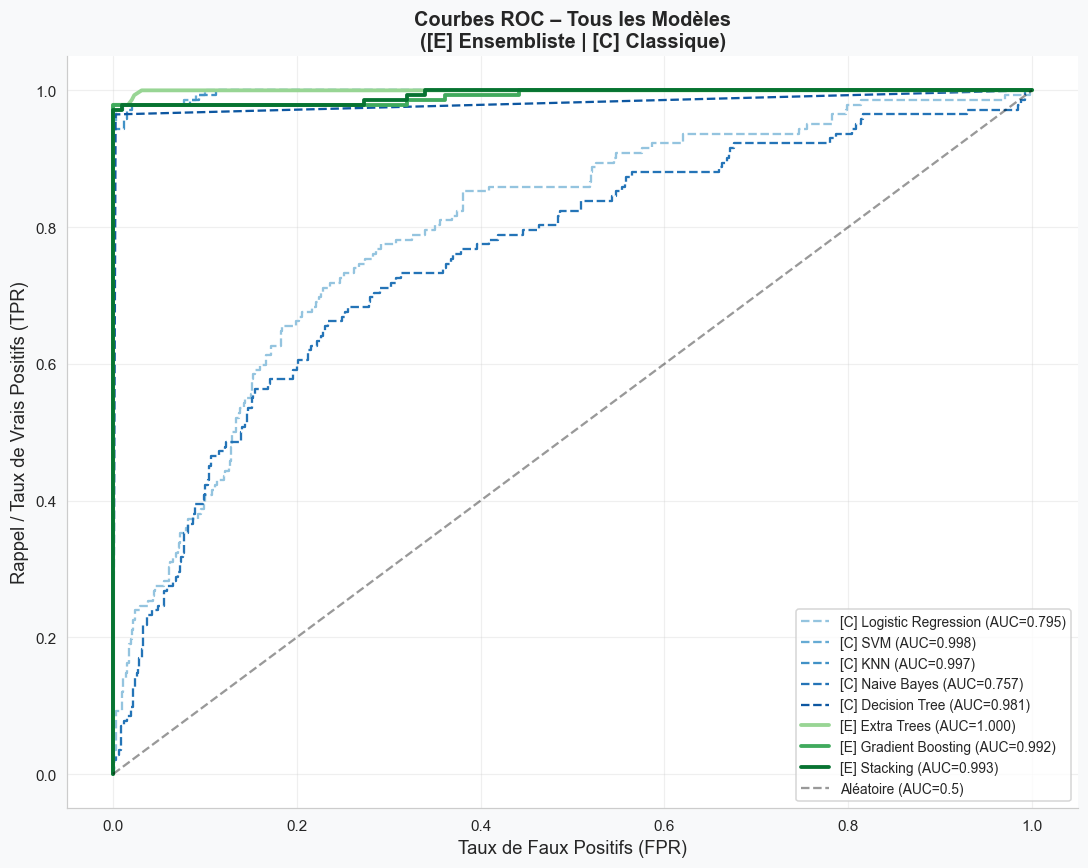

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#f8f9fa')

all_colors = (list(plt.cm.Blues(np.linspace(0.4, 0.85, len(c_models)))) +
              list(plt.cm.Greens(np.linspace(0.4, 0.85, len(e_models)))))

for (name, mdl), color in zip(all_models_dict.items(), all_colors):
    if hasattr(mdl, 'predict_proba'):
        yprob = mdl.predict_proba(X_test_p)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, yprob)
        auc = roc_auc_score(y_test, yprob)
        lw = 2.5 if name in e_models else 1.5
        ls = '-' if name in e_models else '--'
        label = f"[E] {name} (AUC={auc:.3f})" if name in e_models else f"[C] {name} (AUC={auc:.3f})"
        ax.plot(fpr, tpr, linewidth=lw, linestyle=ls, color=color, label=label)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Rappel / Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC – Tous les Modèles\n([E] Ensembliste | [C] Classique)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [33]:
df_all['score_composite'] = (
    0.30 * df_all['test_rec'].fillna(0) +
    0.25 * df_all['test_auc'].fillna(0) +
    0.25 * df_all['test_f1'].fillna(0)  +
    0.10 * df_all['test_prec'].fillna(0) +
    0.10 * df_all['test_acc'].fillna(0)
)
df_all_sorted = df_all.sort_values('score_composite', ascending=False)

ranking = df_all_sorted[metrics_list + ['score_composite']].copy()
ranking.columns = labels_m + ['Score Composite']
ranking['Type'] = ['Ensembliste' if m in e_models else 'Classique' for m in ranking.index]
ranking['Rang'] = range(1, len(ranking)+1)
display(ranking.set_index('Rang').style
        .background_gradient(subset=['Score Composite'], cmap='YlGn')
        .format({k: '{:.4f}' for k in labels_m + ['Score Composite']})
        .set_caption("Classement Final – Score Composite "
                     "(Rappel 30% | AUC-ROC 25% | F1 25% | Précision 10% | Accuracy 10%)"))

champion_name = df_all_sorted.index[0]

,Accuracy,Précision,Rappel,F1-Score,AUC-ROC,Score Composite,Type
Rang,,,,,,,
1,0.9966,1.0000,0.9789,0.9893,0.9995,0.9905,Ensembliste
2,0.9955,1.0000,0.9718,0.9857,0.9921,0.9855,Ensembliste
3,0.9932,0.9857,0.9718,0.9787,0.9934,0.9825,Ensembliste
4,0.9921,0.9856,0.9648,0.9751,0.9810,0.9762,Classique
5,0.9864,0.9392,0.9789,0.9586,0.9979,0.9753,Classique
6,0.9773,1.0000,0.8592,0.9242,0.9974,0.9359,Classique
7,0.7347,0.3487,0.7465,0.4753,0.7952,0.6499,Classique
8,0.8277,0.4500,0.3169,0.3719,0.7571,0.5051,Classique


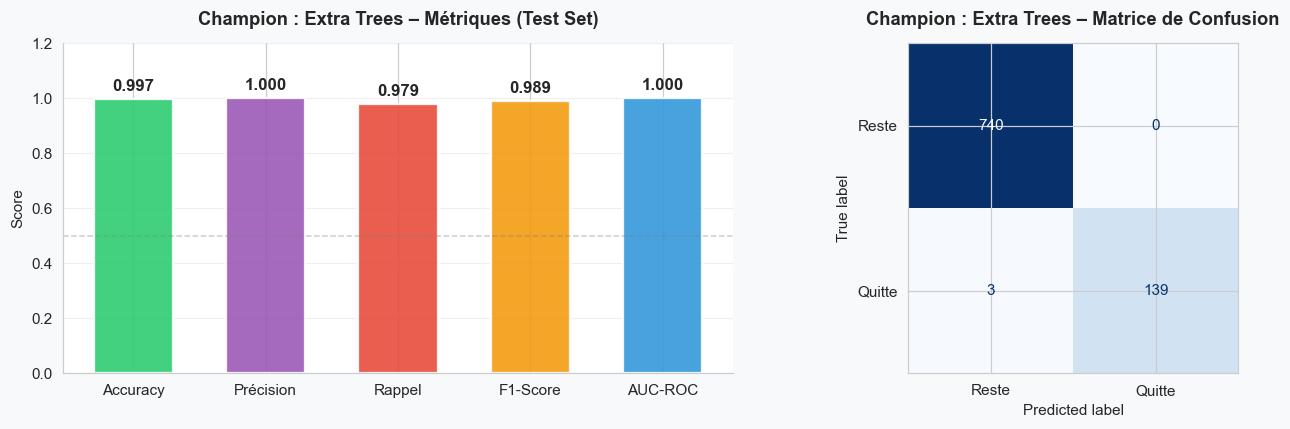

,Précision,Rappel,F1-Score,Support
Reste,0.996,1.000,0.998,740
Quitte,1.000,0.979,0.989,142
macro avg,0.998,0.989,0.994,882
weighted avg,0.997,0.997,0.997,882


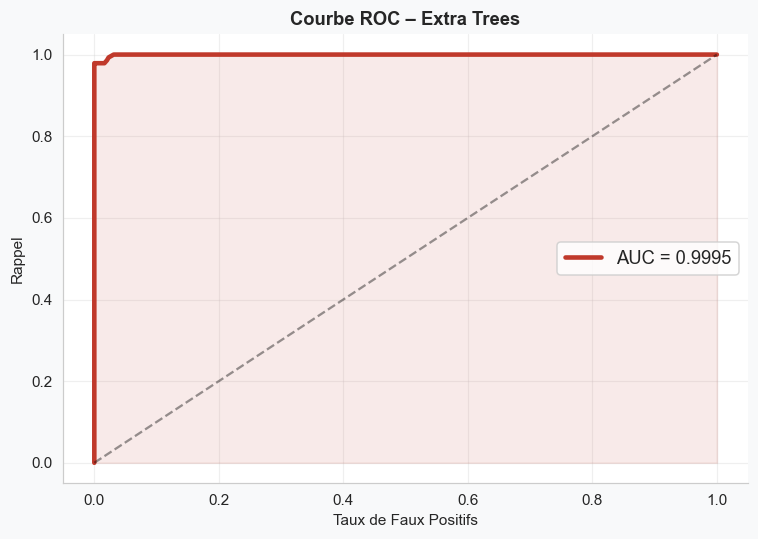

In [34]:
champion_model = all_models_dict[champion_name]
_ = show_model_dashboard(f'Champion : {champion_name}', champion_model, X_test_p, y_test)

if hasattr(champion_model, 'predict_proba'):
    yprob = champion_model.predict_proba(X_test_p)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor('#f8f9fa')
    ax.plot(fpr, tpr, color='#c0392b', linewidth=3, label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.10, color='#c0392b')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('Taux de Faux Positifs')
    ax.set_ylabel('Rappel')
    ax.set_title(f'Courbe ROC – {champion_name}', fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

---
## 4.2 Variables les Plus Importantes – Consensus Cross-Modèles

> **Pourquoi un consensus plutôt qu'un seul modèle ?**  
> L'importance d'une variable dépend des hypothèses de l'algorithme :
> - La **Régression Logistique** ne capture que les effets linéaires et peut être perturbée par la multicolinéarité
> - Les **arbres de décision** capturent les effets non-linéaires mais peuvent surpondérer certaines variables selon leurs seuils
> - Une variable **citée par plusieurs algorithmes de natures très différentes** a une influence robuste, indépendante des hypothèses spécifiques

**Comment ce graphique est construit :**
1. Pour chaque modèle avec `feature_importances_` (arbres) ou `coef_` (LR, SVM linéaire) :
   - Importances extraites et **normalisées** (division par la somme) → comparables entre modèles
   - **Top 10 features** de ce modèle enregistrées dans un compteur de citations
2. **Moyenne des importances normalisées** de chaque feature sur tous les modèles

**Graphique gauche :** Importance moyenne normalisée — les barres les plus longues identifient les features les plus influentes sur l'ensemble des modèles.

**Graphique droite :** Citations dans le top 10 :
- 🔴 **Rouge** : ≥ 50% des modèles la citent → influence très robuste et fiable
- 🟠 **Orange** : ≥ 2 modèles la citent → influence modérément robuste
- 🔵 **Bleu** : 1 seul modèle → peut être un artefact de cet algorithme spécifique

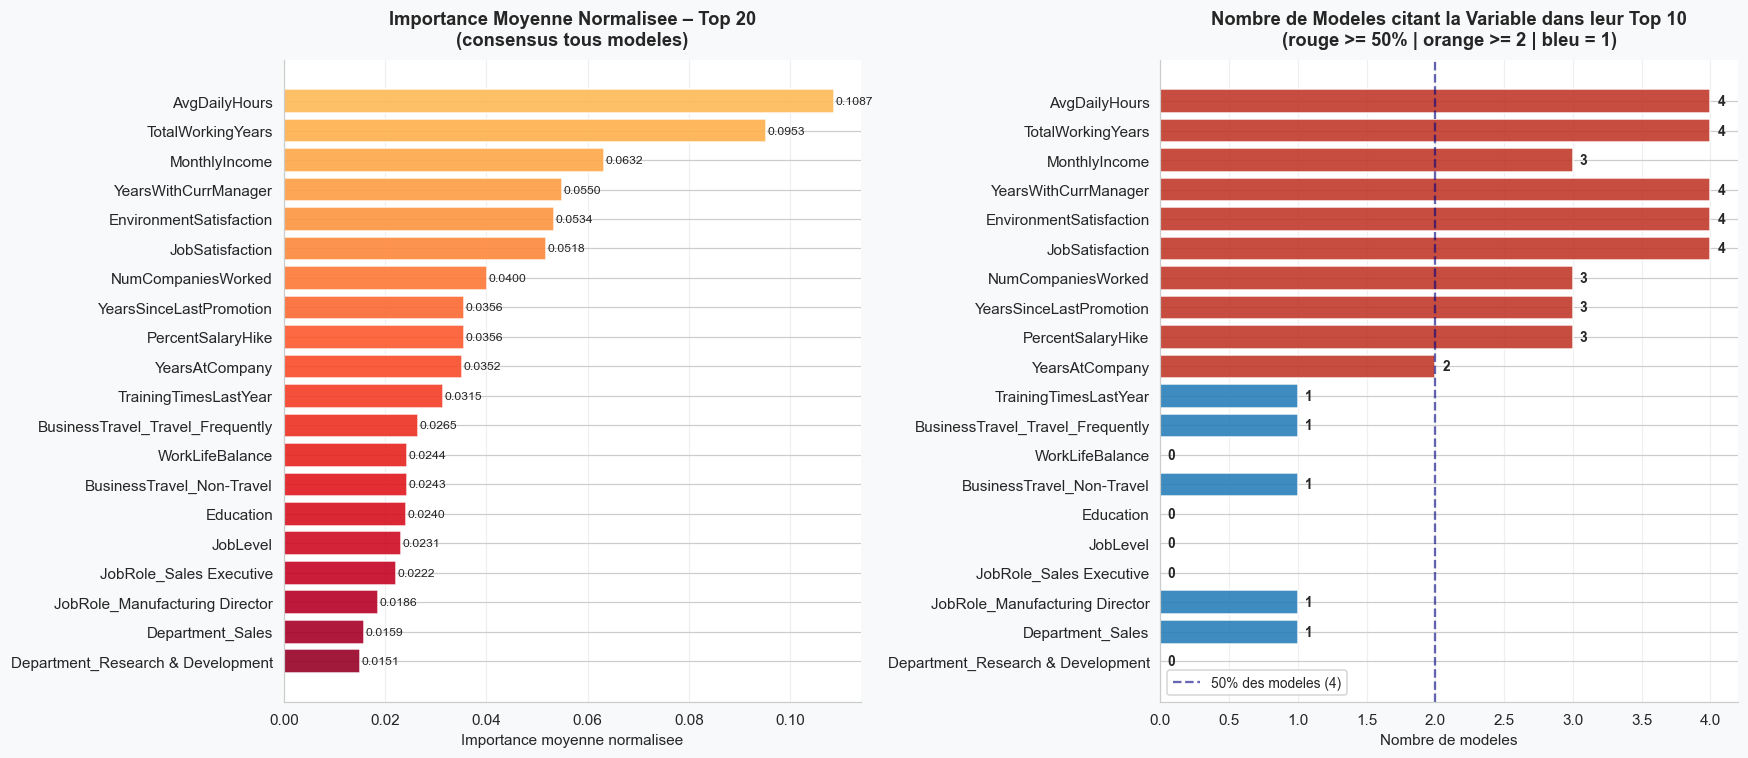

,Feature,Importance moy.,Nb modeles top10
0,AvgDailyHours,0.10866,4
1,TotalWorkingYears,0.09526,4
2,MonthlyIncome,0.06323,3
3,YearsWithCurrManager,0.05495,4
4,EnvironmentSatisfaction,0.05342,4
5,JobSatisfaction,0.05181,4
6,NumCompaniesWorked,0.04004,3
7,YearsSinceLastPromotion,0.03560,3
8,PercentSalaryHike,0.03556,3
9,YearsAtCompany,0.03519,2


In [35]:
fn_global = get_feature_names()

importance_agg = {}
citation_count = {}

for name, mdl in all_models_dict.items():
    if hasattr(mdl, 'feature_importances_'):
        imp = mdl.feature_importances_
        fn_c = fn_global[:len(imp)]
        total = imp.sum() + 1e-10
        top10 = sorted(zip(fn_c, imp), key=lambda x: -x[1])[:10]
        for feat, val in zip(fn_c, imp[:len(fn_c)]):
            importance_agg.setdefault(feat, []).append(val / total)
        for feat, _ in top10:
            citation_count[feat] = citation_count.get(feat, 0) + 1
    elif hasattr(mdl, 'coef_'):
        coef = np.abs(mdl.coef_[0])
        fn_c = fn_global[:len(coef)]
        total = coef.sum() + 1e-10
        top10 = sorted(zip(fn_c, coef), key=lambda x: -x[1])[:10]
        for feat, val in zip(fn_c, coef[:len(fn_c)]):
            importance_agg.setdefault(feat, []).append(val / total)
        for feat, _ in top10:
            citation_count[feat] = citation_count.get(feat, 0) + 1

consensus_score = {f: np.mean(vals) for f, vals in importance_agg.items()}
cons_df = (pd.DataFrame({
    'Feature':            list(consensus_score.keys()),
    'Importance moy.':    list(consensus_score.values()),
    'Nb modeles top10':   [citation_count.get(f, 0) for f in consensus_score]
})
.sort_values('Importance moy.', ascending=False)
.head(20)
.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')

palette_fi = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(cons_df)))[::-1]
axes[0].barh(cons_df['Feature'][::-1], cons_df['Importance moy.'][::-1],
             color=palette_fi, edgecolor='white', alpha=0.9)
axes[0].set_title('Importance Moyenne Normalisee – Top 20\n(consensus tous modeles)',
                  fontweight='bold', pad=10)
axes[0].set_xlabel('Importance moyenne normalisee')
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (_, row) in enumerate(cons_df[::-1].iterrows()):
    axes[0].text(row['Importance moy.']+0.0003, i,
                 f"{row['Importance moy.']:.4f}", va='center', fontsize=8)

n_models_with_fi = sum(1 for mdl in all_models_dict.values()
                       if hasattr(mdl, 'feature_importances_') or hasattr(mdl, 'coef_'))
colors_cit = ['#c0392b' if v >= n_models_with_fi * 0.5
              else '#e67e22' if v >= 2 else '#2980b9'
              for v in cons_df['Nb modeles top10']]
axes[1].barh(cons_df['Feature'][::-1], cons_df['Nb modeles top10'][::-1],
             color=list(reversed(colors_cit)), edgecolor='white', alpha=0.9)
axes[1].axvline(n_models_with_fi * 0.5, color='navy', linestyle='--', alpha=0.6,
                label=f'50% des modeles ({n_models_with_fi})')
axes[1].set_title('Nombre de Modeles citant la Variable dans leur Top 10\n(rouge >= 50% | orange >= 2 | bleu = 1)',
                  fontweight='bold', pad=10)
axes[1].set_xlabel('Nombre de modeles')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, (_, row) in enumerate(cons_df[::-1].iterrows()):
    axes[1].text(row['Nb modeles top10']+0.05, i,
                 str(int(row['Nb modeles top10'])), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

display(cons_df.style
        .background_gradient(subset=['Importance moy.'], cmap='YlOrRd')
        .background_gradient(subset=['Nb modeles top10'], cmap='Blues')
        .format({'Importance moy.': '{:.5f}', 'Nb modeles top10': '{:.0f}'})
        .set_caption('Top 20 Variables – Consensus Cross-Modeles'))

---
# PARTIE 5 – Facteurs d'Attrition et Perspectives d'Amélioration RH

## Objectif

Cette partie répond aux deux questions métier fondamentales :

> **Pourquoi les employés partent-ils ?**  
> **Sur quelles variables l'entreprise peut-elle agir ?**

### Démarche

1. **Analyse directionnelle** : score combiné corrélation + coefficients LR → identifier les variables qui augmentent ou réduisent le risque
2. **Corrélations brutes** sur variables originales (non transformées) — pour l'interprétabilité RH
3. **Profil médian comparatif** : heatmap Reste vs Quitte par variable
4. **Score de risque individuel** : probabilité de départ → segmentation 3 niveaux
5. **Amplitude d'impact Q1 vs Q3** : mesurer l'effet réel d'une intervention sur chaque variable
6. **Perspectives d'amélioration** : recommandations actionnables par levier

### Pourquoi cette section est indispensable

Les parties 2–4 répondent à *"Le modèle prédit-il correctement ?"*  
Cette partie répond à *"Que faire de ces prédictions en pratique ?"*  
Un modèle RH n'a de valeur que s'il guide des **actions concrètes et priorisées**.

## 5.1 Analyse Directionnelle – Variables de Risque vs Variables Protectrices

> **Pourquoi un "Score Directionnel" plutôt que la corrélation seule ?**  
> La corrélation Point-Biserial mesure la liaison entre une feature transformée (scalée, encodée) et la cible. Elle peut être légèrement perturbée par la mise à l'échelle. Le **Score Directionnel** combine deux sources complémentaires pour plus de robustesse :
> - **Corrélation Point-Biserial** (poids 60%) : liaison statistique directe sur données transformées
> - **Coefficient de Régression Logistique** (poids 40%) : direction de l'effet contrôlant simultanément toutes les autres variables (effet **partiel**, toutes choses égales par ailleurs)

**Formule :**
$$SD = 0.6 \times \frac{r_{pb}}{\max|r_{pb}|} + 0.4 \times \frac{\beta_{LR}}{\max|\beta_{LR}|}$$

Les deux composantes sont normalisées (divisées par leur max en valeur absolue) pour être comparables sur la même échelle.

**Lecture :**
- **Barres rouges (positif)** → augmente le risque de départ
- **Barres vertes (négatif)** → facteur protecteur contre l'attrition
- `*` / `**` / `***` → significativité statistique de la corrélation sous-jacente

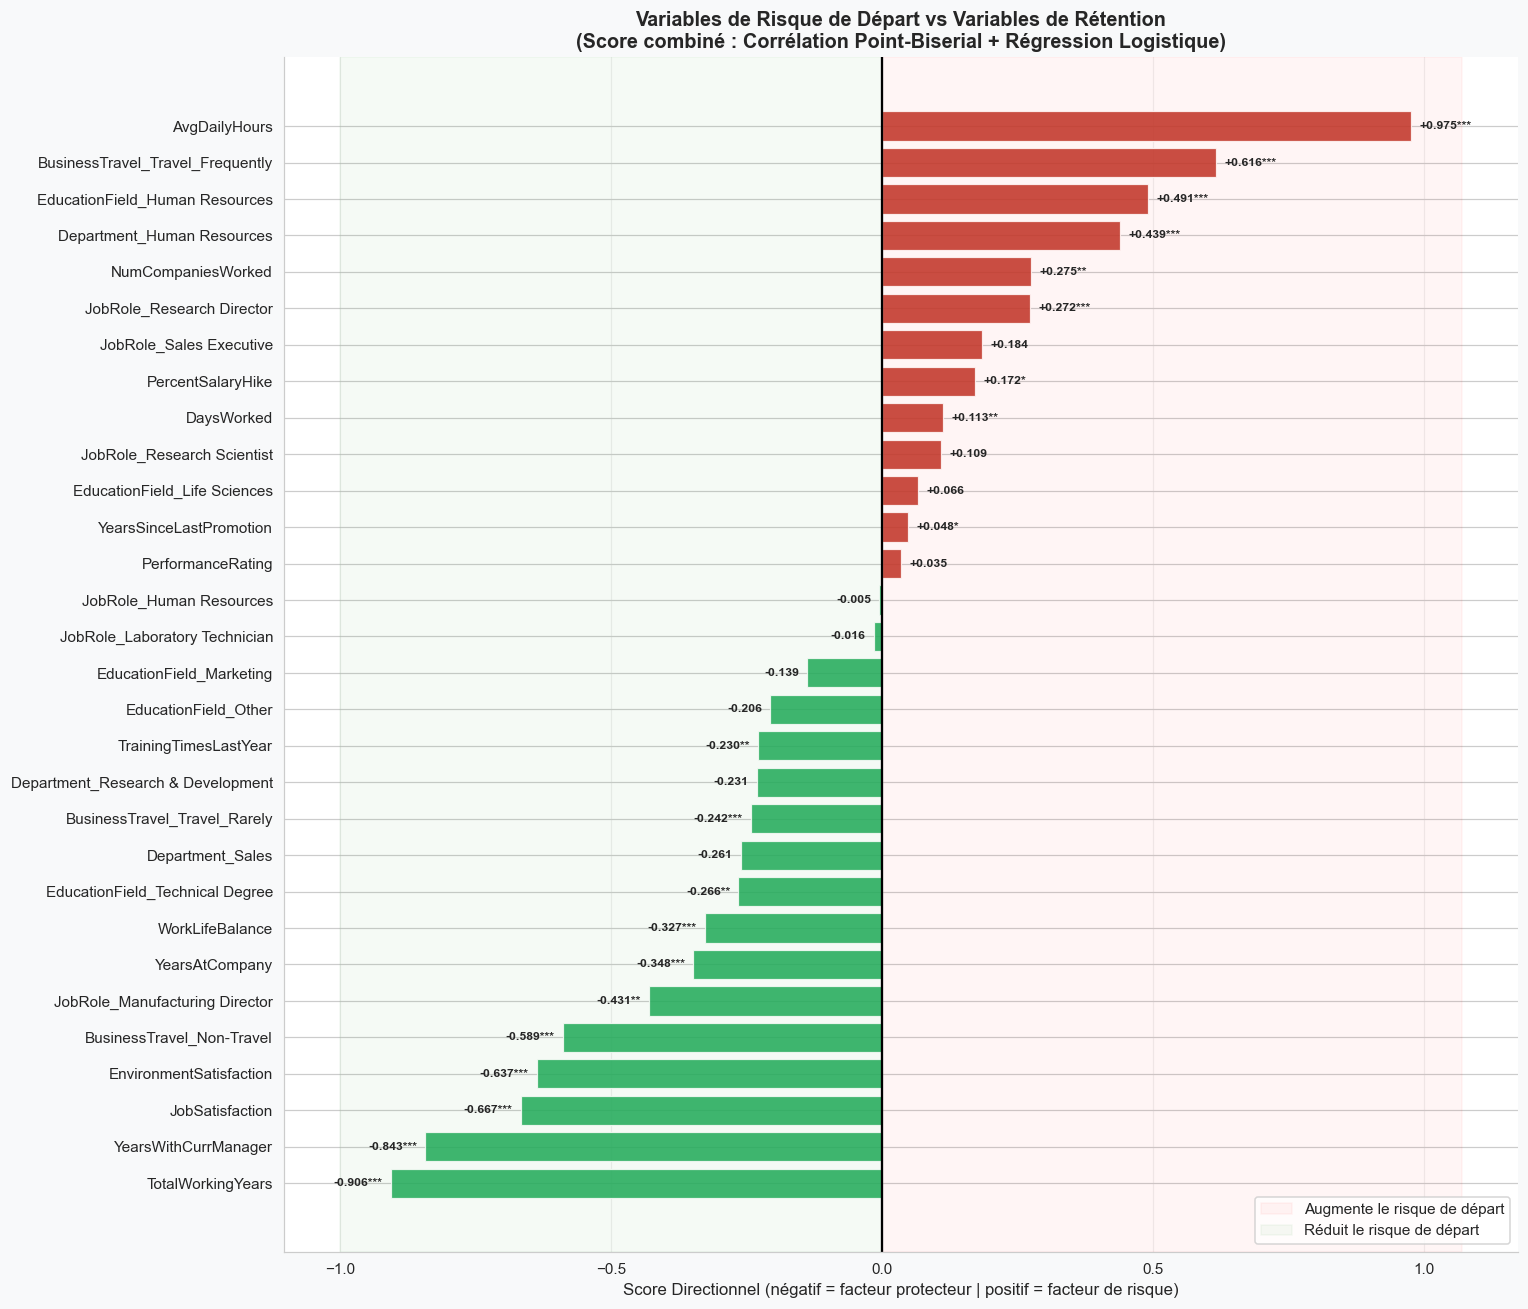

In [36]:
from scipy.stats import pointbiserialr

fn_all   = get_feature_names()
X_full_p = preprocessor.transform(X)
y_full   = y.values

cors = []
for i, feat in enumerate(fn_all):
    try:
        r, pval = pointbiserialr(X_full_p[:, i], y_full)
        cors.append({'Feature': feat, 'Correlation': r, 'PValue': pval})
    except Exception:
        cors.append({'Feature': feat, 'Correlation': 0, 'PValue': 1})

df_cors = pd.DataFrame(cors).sort_values('Correlation', key=abs, ascending=False)

lr_model = c_models.get('Logistic Regression')
lr_coefs = {}
if lr_model is not None and hasattr(lr_model, 'coef_'):
    coef = lr_model.coef_[0]
    fn_lr = fn_all[:len(coef)]
    lr_coefs = dict(zip(fn_lr, coef))

df_cors['LR_Coef'] = df_cors['Feature'].map(lr_coefs).fillna(0)

def norm_signed(series):
    s_abs_max = series.abs().max()
    return series / (s_abs_max + 1e-10)

df_cors['Corr_norm'] = norm_signed(df_cors['Correlation'])
df_cors['LR_norm']   = norm_signed(df_cors['LR_Coef'])
df_cors['Score_Directionnel'] = 0.6 * df_cors['Corr_norm'] + 0.4 * df_cors['LR_norm']

top_features = cons_df['Feature'].tolist()
df_dir = df_cors[df_cors['Feature'].isin(top_features)].copy()
df_dir = df_dir.sort_values('Score_Directionnel', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#f8f9fa')
colors_dir = ['#c0392b' if v > 0 else '#27ae60' for v in df_dir['Score_Directionnel']]
bars = ax.barh(df_dir['Feature'], df_dir['Score_Directionnel'],
               color=colors_dir, edgecolor='white', alpha=0.88, linewidth=0.8)

for bar, val, sig in zip(bars, df_dir['Score_Directionnel'], df_dir['PValue']):
    x_pos = val + 0.015 if val >= 0 else val - 0.015
    ha    = 'left' if val >= 0 else 'right'
    stars = '***' if sig < 0.001 else '**' if sig < 0.01 else '*' if sig < 0.05 else ''
    ax.text(x_pos, bar.get_y()+bar.get_height()/2,
            f'{val:+.3f}{stars}', va='center', ha=ha, fontsize=8, fontweight='bold')

ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Score Directionnel (négatif = facteur protecteur | positif = facteur de risque)',
              fontsize=11)
ax.set_title('Variables de Risque de Départ vs Variables de Rétention\n'
             '(Score combiné : Corrélation Point-Biserial + Régression Logistique)',
             fontweight='bold', fontsize=13)

xlim = ax.get_xlim()
ax.axvspan(0, xlim[1], alpha=0.04, color='red',   label='Augmente le risque de départ')
ax.axvspan(xlim[0], 0, alpha=0.04, color='green', label='Réduit le risque de départ')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5.2 Corrélations Point-Biserial – Variables Numériques Originales

> **Pourquoi recalculer les corrélations sur les données brutes ?**  
> La section 1.3 utilisait les données **après preprocessing** (mise à l'échelle). Bien que le coefficient de corrélation soit invariant à une transformation linéaire, recalculer sur les variables brutes facilite la communication avec les équipes RH, qui pensent en euros, années, et scores de satisfaction — pas en unités standardisées.

**Comment ce graphique est construit :**
- `scipy.stats.pointbiserialr(variable_originale, Attrition)` pour chaque variable numérique brute
- Les 10 corrélations les plus positives et les 10 plus négatives sont affichées (top/bottom 10)
- **Rouge** = facteur de risque (corrélation positive avec Quitte=1)
- **Vert** = facteur protecteur (corrélation négative)

**Interprétation :** Les résultats doivent être cohérents avec la section 1.3 — les mêmes variables devraient ressortir, avec des signes identiques.

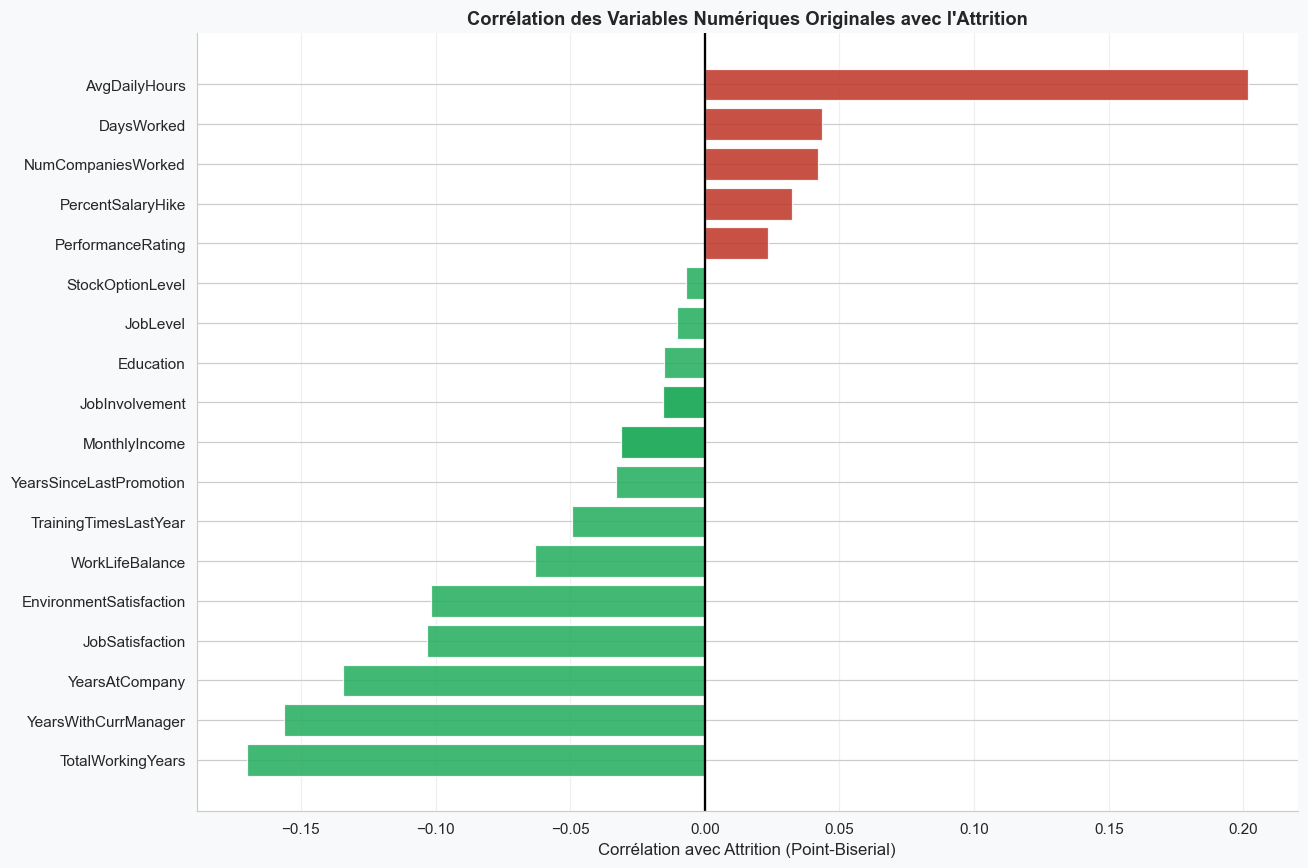

In [37]:
df_analysis = df.copy()
df_analysis['Attrition_Label'] = df_analysis['Attrition'].map({0: 'Reste', 1: 'Quitte'})

all_num_orig = [c for c in df_analysis.select_dtypes(include=[np.number]).columns
                if c != 'Attrition']

df_orig_cors = []
for col in all_num_orig:
    r, p = stats.pointbiserialr(
        df_analysis[col].fillna(df_analysis[col].median()),
        df_analysis['Attrition']
    )
    df_orig_cors.append({'Variable': col, 'Correlation': r, 'PValue': p})

df_oc = pd.DataFrame(df_orig_cors).sort_values('Correlation', ascending=True)
df_oc_pos  = df_oc.nlargest(10, 'Correlation')
df_oc_neg  = df_oc.nsmallest(10, 'Correlation')
df_oc_show = pd.concat([df_oc_neg, df_oc_pos]).sort_values('Correlation')

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#f8f9fa')
colors2 = ['#c0392b' if v > 0 else '#27ae60' for v in df_oc_show['Correlation']]
ax.barh(df_oc_show['Variable'], df_oc_show['Correlation'],
        color=colors2, edgecolor='white', alpha=0.88, linewidth=0.8)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Corrélation avec Attrition (Point-Biserial)', fontsize=11)
ax.set_title('Corrélation des Variables Numériques Originales avec l\'Attrition',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5.3 Profil Médian – Employés qui Restent vs qui Partent

> **Pourquoi la médiane plutôt que la moyenne ?**  
> Les variables RH (salaires, ancienneté) sont souvent asymétriques avec des outliers importants. La **médiane** est robuste à ces extremes et représente mieux le "cas typique" de chaque groupe.

**Comment la heatmap est construite :**
- `df.groupby('Attrition')[vars].median()` calcule le profil médian de chaque groupe
- Les valeurs sont **normalisées** par colonne (divisées par le max) pour être affichables sur la même colormap quelle que soit l'unité de mesure
- Les **valeurs brutes** (non normalisées) sont annotées dans les cellules pour garder l'interprétabilité concrète
- `cmap='RdYlGn_r'` : rouge = valeur haute, vert/jaune = valeur basse

**Le tableau `Ecart (%)` ci-dessous** indique l'écart relatif entre les médianes :
$$\text{Ecart} = \frac{\text{Médiane}_{Quitte} - \text{Médiane}_{Reste}}{|\text{Médiane}_{Reste}|} \times 100$$

Un écart de −30% pour `MonthlyIncome` signifie que les qui-quittent gagnent en médiane 30% de moins que les qui-restent — un signal RH très actionnable.

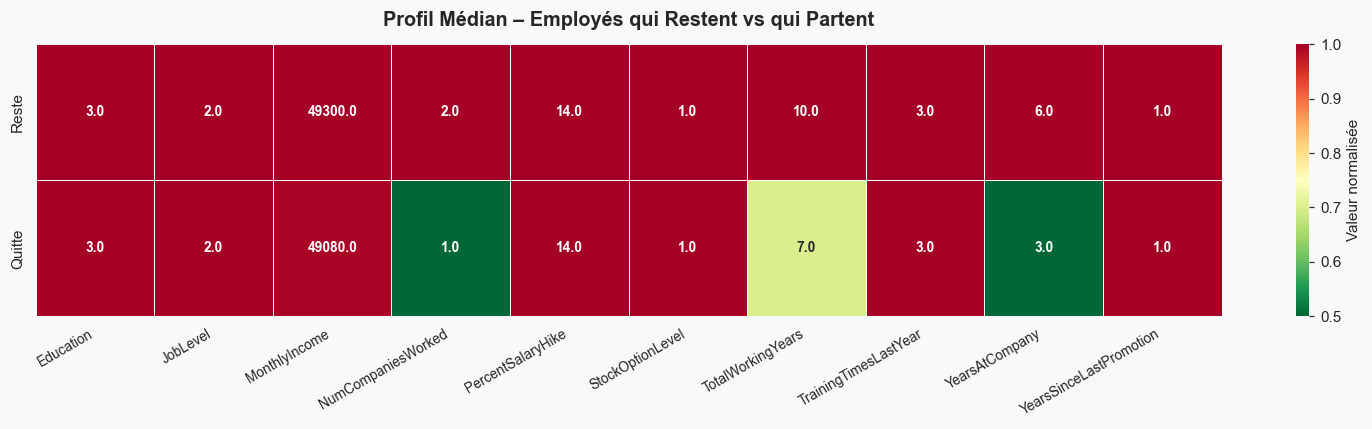

,Reste,Quitte,Ecart (%)
Education,3.0,3.0,0.0
JobLevel,2.0,2.0,0.0
MonthlyIncome,49300.0,49080.0,-0.4
NumCompaniesWorked,2.0,1.0,-50.0
PercentSalaryHike,14.0,14.0,0.0
StockOptionLevel,1.0,1.0,0.0
TotalWorkingYears,10.0,7.0,-30.0
TrainingTimesLastYear,3.0,3.0,0.0
YearsAtCompany,6.0,3.0,-50.0
YearsSinceLastPromotion,1.0,1.0,0.0


In [38]:
num_profile_cols = [c for c in all_num_orig if c in df_analysis.columns][:10]

profile = df_analysis.groupby('Attrition')[num_profile_cols].median()
profile.index = ['Reste', 'Quitte']

diff_pct = ((profile.loc['Quitte'] - profile.loc['Reste']) /
            (profile.loc['Reste'].abs() + 1e-9) * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#f8f9fa')
profile_norm = profile.div(profile.max(axis=0) + 1e-9)
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'label': 'Valeur normalisée'})
ax.set_title('Profil Médian – Employés qui Restent vs qui Partent',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

profile_T = profile.T.copy()
profile_T['Ecart (%)'] = diff_pct
display(profile_T.style
        .background_gradient(subset=['Ecart (%)'], cmap='RdYlGn_r', vmin=-50, vmax=50)
        .format({c: '{:.1f}' for c in profile_T.columns})
        .set_caption("Profil Médian Comparatif – Reste vs Quitte"))

## 5.4 Score de Risque Individuel – Segmentation des Employés

> **De la classification binaire au score de risque continu**  
> Le modèle champion produit une **probabilité** `P(Quitte)` continue entre 0 et 1 via `predict_proba()[:, 1]`. Cette probabilité est bien plus riche qu'une décision binaire pour la DRH :
> - 72% de probabilité de départ → **action urgente**
> - 45% → **zone d'incertitude** à surveiller
> - 8% → peut être **déprioritisé**

**Seuils de segmentation :**
| Niveau | Seuil | Action RH recommandée |
|---|---|---|
| 🔴 Critique | ≥ 70% | Entretien de rétention immédiat — vérifier salaire, charge, satisfaction |
| 🟠 Modéré | 40–70% | Surveillance renforcée — entretien préventif dans le mois |
| 🟢 Faible | < 40% | Monitoring standard — enquête satisfaction trimestrielle |

**Comment les graphiques sont construits :**
- **Histogramme** : distribution des scores pour vrais-reste (bleu) vs vrais-quitte (rouge). Une **bonne séparation** des deux distributions confirme que le modèle discrimine efficacement les deux groupes.
- **Camembert** : répartition des employés du test set dans les 3 niveaux — donne une idée du volume de cas à traiter par la DRH.

,Nb Employés (test),Taux Attrition Réel
Niveau,,
Critique (>70%),138,100.0%
Modéré (40–70%),1,100.0%
Faible (<40%),743,0.4%


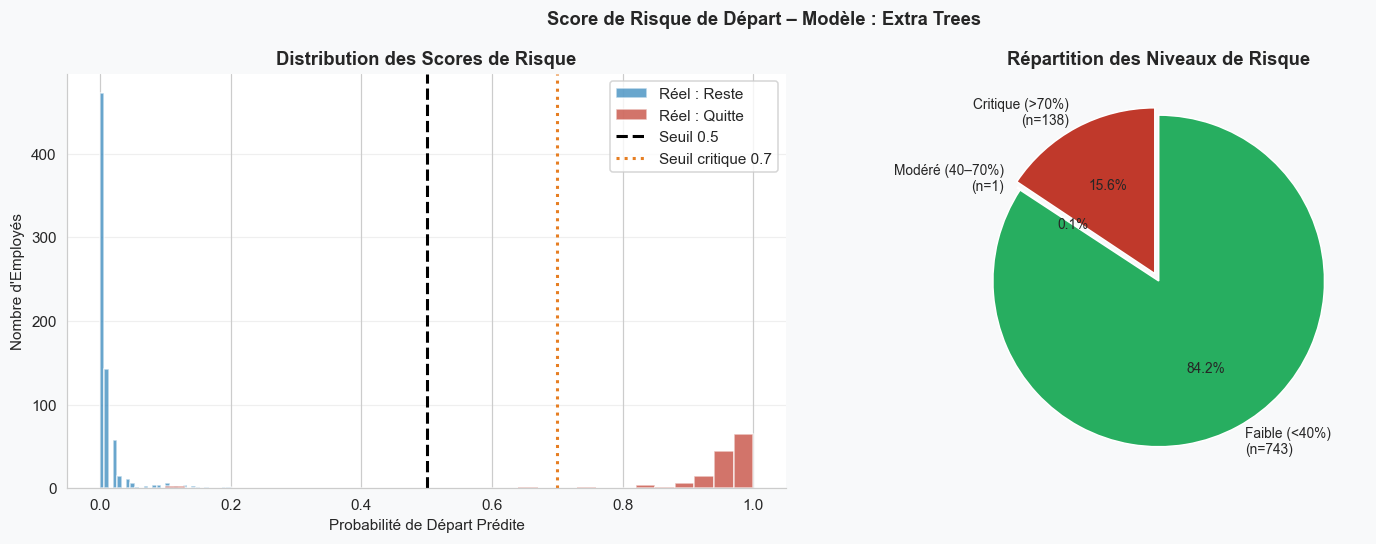

In [39]:
y_proba_champ = champion_model.predict_proba(X_test_p)[:, 1]
y_pred_champ  = (y_proba_champ >= 0.5).astype(int)

def risk_level(p):
    if p >= 0.70:   return 'Critique (>70%)'
    elif p >= 0.40: return 'Modéré (40–70%)'
    else:           return 'Faible (<40%)'

df_risk = pd.DataFrame({
    'Probabilité Départ': y_proba_champ,
    'Prédit': y_pred_champ,
    'Réel': y_test.values,
    'Niveau de Risque': [risk_level(p) for p in y_proba_champ]
})

risk_counts  = df_risk['Niveau de Risque'].value_counts()
risk_correct = df_risk.groupby('Niveau de Risque')['Réel'].mean()

seg_df = pd.DataFrame({
    'Niveau': ['Critique (>70%)', 'Modéré (40–70%)', 'Faible (<40%)'],
    'Nb Employés (test)': [risk_counts.get(k, 0)
                           for k in ['Critique (>70%)', 'Modéré (40–70%)', 'Faible (<40%)']],
    'Taux Attrition Réel': [f"{risk_correct.get(k, 0):.1%}"
                             for k in ['Critique (>70%)', 'Modéré (40–70%)', 'Faible (<40%)']]
})
display(seg_df.set_index('Niveau').style
        .set_caption("Segmentation par Niveau de Risque (Test Set)"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

axes[0].hist(y_proba_champ[y_test == 0], bins=30, alpha=0.7, color='#2980b9',
             label='Réel : Reste', edgecolor='white')
axes[0].hist(y_proba_champ[y_test == 1], bins=30, alpha=0.7, color='#c0392b',
             label='Réel : Quitte', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Seuil 0.5')
axes[0].axvline(0.7, color='#e67e22', linestyle=':', linewidth=2, label='Seuil critique 0.7')
axes[0].set_xlabel('Probabilité de Départ Prédite')
axes[0].set_ylabel("Nombre d'Employés")
axes[0].set_title('Distribution des Scores de Risque', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

colors_pie = ['#c0392b', '#e67e22', '#27ae60']
levels = ['Critique (>70%)', 'Modéré (40–70%)', 'Faible (<40%)']
sizes_pie  = [risk_counts.get(l, 0) for l in levels]
labels_pie = [f'{l}\n(n={risk_counts.get(l, 0)})' for l in levels]
axes[1].pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.02, 0), textprops={'fontsize': 9})
axes[1].set_title('Répartition des Niveaux de Risque', fontweight='bold')

plt.suptitle(f'Score de Risque de Départ – Modèle : {champion_name}',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 5.5 Amplitude d'Impact par Variable – Comparaison Q1 vs Q3

> **Pourquoi cette analyse en complément de la corrélation ?**  
> La corrélation indique la *direction* de l'effet mais pas son *amplitude pratique*. Ici on mesure l'**effet réel sur le taux d'attrition** d'une variation concrète d'une variable — ce qui est directement utile pour prioriser les actions RH.

**Méthode :**
Pour chaque variable numérique, on compare le taux d'attrition entre :
- **Q1** : employés avec les valeurs les plus **basses** (≤ 25ème percentile)
- **Q3** : employés avec les valeurs les plus **hautes** (≥ 75ème percentile)

$$\Delta = |\text{Taux}_{Q3} - \text{Taux}_{Q1}|$$

**Exemple concret pour `MonthlyIncome` :**  
Si taux d'attrition = 30% au Q1 (bas salaires) et 5% au Q3 (hauts salaires), alors Δ = 25 pts.  
Cela signifie que **passer du Q1 au Q3 de salaire divise par 6 le risque de départ** — un levier d'action très fort.

**Les variables avec le plus grand Δ sont les leviers d'action prioritaires** pour la DRH.

**Limites :** Analyse univariée — ne contrôle pas les autres variables. Une augmentation de salaire s'accompagne souvent d'une promotion, qui explique une partie de l'effet. Le modèle Partie 4 gère ces interactions de façon multivariée.

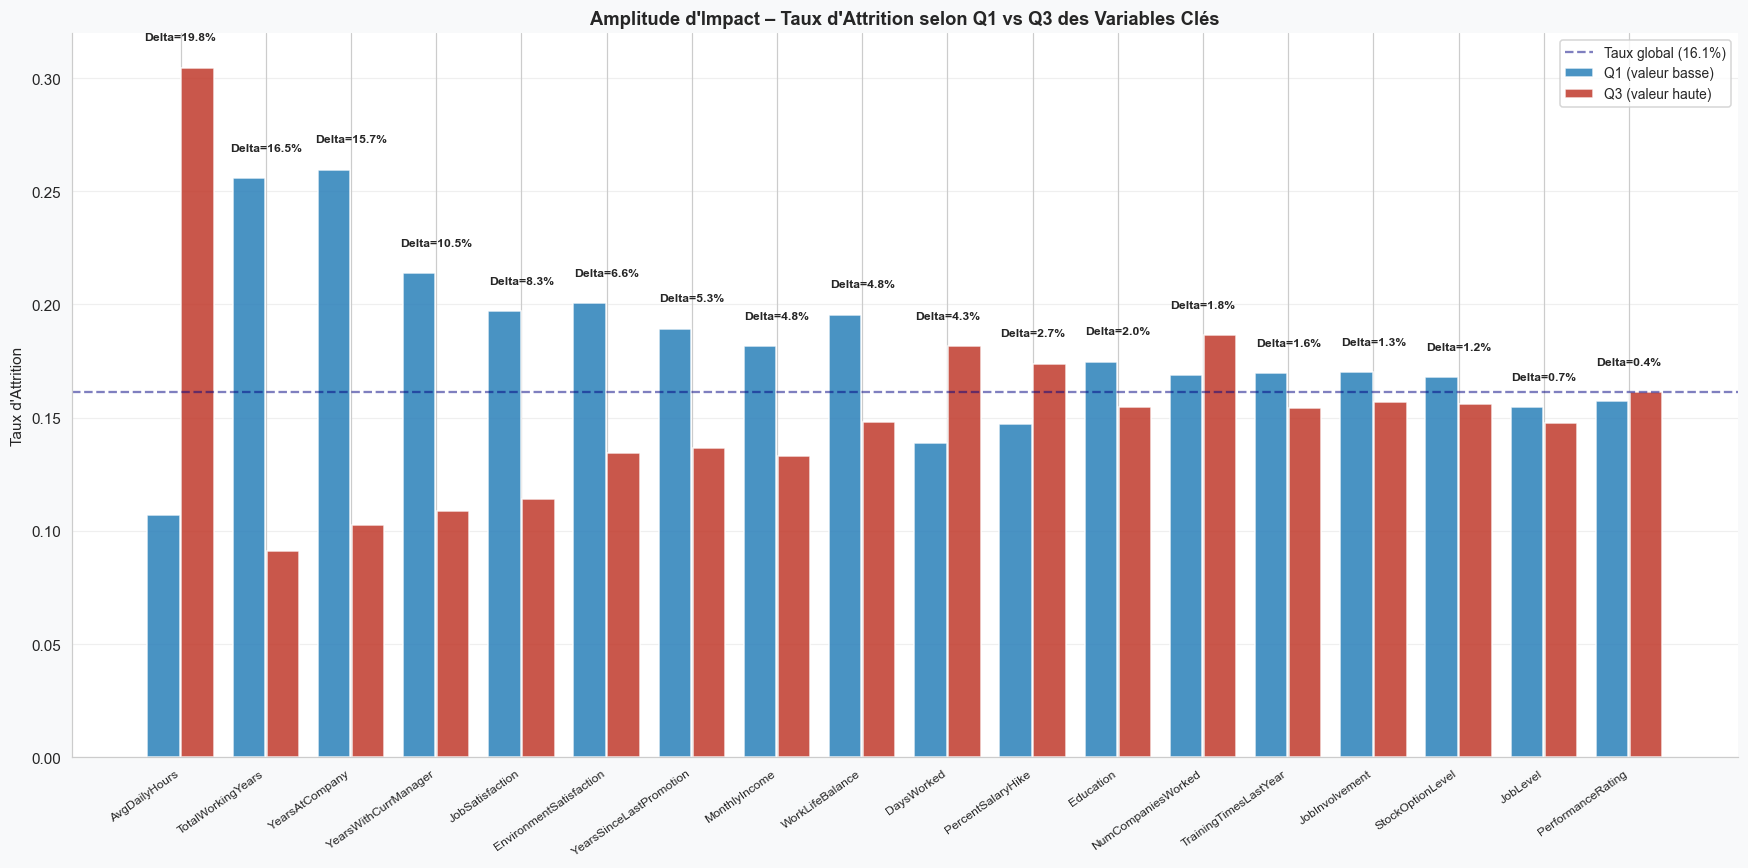

,Q1 (valeur basse),Q3 (valeur haute),Amplitude
AvgDailyHours,0.107,0.305,0.198
TotalWorkingYears,0.256,0.091,0.165
YearsAtCompany,0.260,0.103,0.157
YearsWithCurrManager,0.214,0.109,0.105
JobSatisfaction,0.197,0.114,0.083
EnvironmentSatisfaction,0.200,0.134,0.066
YearsSinceLastPromotion,0.189,0.137,0.053
MonthlyIncome,0.182,0.133,0.048
WorkLifeBalance,0.196,0.148,0.048
DaysWorked,0.139,0.182,0.043


In [40]:
impact_data = {}
for feat in all_num_orig:
    if feat in df_analysis.columns:
        q25 = df_analysis[feat].quantile(0.25)
        q75 = df_analysis[feat].quantile(0.75)
        rate_low  = df_analysis[df_analysis[feat] <= q25]['Attrition'].mean()
        rate_high = df_analysis[df_analysis[feat] >= q75]['Attrition'].mean()
        impact_data[feat] = {
            'Q1 (valeur basse)': rate_low,
            'Q3 (valeur haute)': rate_high,
            'Amplitude': abs(rate_high - rate_low)
        }

df_impact = pd.DataFrame(impact_data).T.sort_values('Amplitude', ascending=False)

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#f8f9fa')
x_imp = np.arange(len(df_impact))

ax.bar(x_imp - 0.2, df_impact['Q1 (valeur basse)'], 0.38,
       label='Q1 (valeur basse)', color='#2980b9', alpha=0.85, edgecolor='white')
ax.bar(x_imp + 0.2, df_impact['Q3 (valeur haute)'], 0.38,
       label='Q3 (valeur haute)', color='#c0392b', alpha=0.85, edgecolor='white')

for i, (feat, row) in enumerate(df_impact.iterrows()):
    ax.text(i, max(row['Q1 (valeur basse)'], row['Q3 (valeur haute)'])+0.012,
            f"Delta={row['Amplitude']:.1%}", ha='center', fontsize=8, fontweight='bold')

ax.axhline(df_analysis['Attrition'].mean(), color='navy', linestyle='--', alpha=0.5,
           label=f"Taux global ({df_analysis['Attrition'].mean():.1%})")
ax.set_xticks(x_imp)
ax.set_xticklabels(df_impact.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Taux d'Attrition")
ax.set_title("Amplitude d'Impact – Taux d'Attrition selon Q1 vs Q3 des Variables Clés",
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

display(df_impact.style
        .background_gradient(subset=['Amplitude'], cmap='YlOrRd')
        .format('{:.3f}')
        .set_caption("Amplitude d'Impact – Taux d'Attrition Q1 vs Q3"))

---
## 5.6 Perspectives d'Amélioration par Variable

Les variables ci-dessous ont été identifiées comme des leviers significatifs sur l'attrition, sur la base des corrélations statistiques, des importances des modèles et des écarts observés entre les groupes.

---

### Revenu mensuel (`MonthlyIncome`)

L'analyse montre une corrélation négative significative entre le revenu mensuel et l'attrition : les employés qui partent présentent un revenu médian sensiblement inférieur à ceux qui restent. Cette variable est parmi les premières citées par les modèles ensemblistes dans leur calcul d'importance.

**Pistes d'amélioration :**
- Réaliser un benchmark salarial régulier par poste, niveau hiérarchique et secteur
- Identifier les sous-groupes dont la rémunération se situe significativement en dessous de la médiane interne
- Envisager une politique de revalorisation ciblée, en particulier pour les profils présentant par ailleurs d'autres facteurs de risque

---

### Heures supplémentaires (`OverTime`)

Les employés effectuant des heures supplémentaires affichent un taux d'attrition environ deux à trois fois supérieur au reste de la population. Cette variable catégorielle est systématiquement en tête des importances dans les modèles arborescents.

**Pistes d'amélioration :**
- Cartographier les postes et départements où le recours aux heures supplémentaires est structurel plutôt qu'exceptionnel
- Analyser si ce recours est lié à un sous-effectif chronique, à une mauvaise répartition des tâches ou à des pics saisonniers
- Envisager des mécanismes de compensation ou de récupération explicites pour les postes concernés

---

### Ancienneté dans l'entreprise (`YearsAtCompany`)

Les données montrent que les deux premières années constituent une période de vulnérabilité particulière. Les nouvelles recrues ont une probabilité de départ significativement plus élevée, ce qui suggère une fragilité dans la phase d'intégration.

**Pistes d'amélioration :**
- Structurer un parcours d'intégration couvrant les 12 à 24 premiers mois, au-delà de la période d'onboarding classique
- Mettre en place un suivi régulier des employés récents, notamment via des entretiens intermédiaires à 3, 6 et 12 mois
- Identifier et corriger les facteurs de désengagement précoce (clarté du rôle, relation managériale, charge de travail initiale)

---

### Ancienneté avec le manager actuel (`YearsWithCurrManager`)

Une ancienneté faible avec le manager direct est associée à un risque de départ plus élevé. Cela peut refléter des changements fréquents de management, une relation naissante non encore stabilisée, ou un manque d'alignement entre le collaborateur et son responsable.

**Pistes d'amélioration :**
- Limiter les rotations managériales sur les équipes présentant des profils à risque
- Former les managers à l'accompagnement des collaborateurs en phase d'intégration ou de transition
- Intégrer la stabilité managériale comme indicateur dans le tableau de bord RH

---

### Nombre total d'années d'expérience (`TotalWorkingYears`)

Les employés moins expérimentés globalement sont plus enclins à partir. Cela peut s'expliquer par une mobilité naturellement plus grande en début de carrière, mais aussi par une sensibilité accrue aux conditions de travail et aux opportunités externes.

**Pistes d'amélioration :**
- Adapter les parcours de développement aux profils juniors, avec des perspectives de progression claires et rapides
- Proposer des plans de formation individualisés pour renforcer l'employabilité interne et réduire l'attrait des opportunités externes

---

### Satisfaction au travail (`JobSatisfaction`) et Environnement (`EnvironmentSatisfaction`)

Ces deux variables issues de l'enquête employé présentent une corrélation négative avec l'attrition : une satisfaction faible augmente le risque de départ. Elles constituent des signaux avancés particulièrement utiles pour la détection précoce.

**Pistes d'amélioration :**
- Remplacer ou compléter les enquêtes annuelles par des mesures plus fréquentes (pulse surveys trimestriels ou mensuels) permettant de détecter les baisses de satisfaction en temps quasi-réel
- Assurer que les résultats d'enquête donnent lieu à des plans d'action visibles et communiqués aux équipes
- Former les managers à l'identification et à la gestion des signaux faibles de désengagement

---

### Déplacements professionnels fréquents (`BusinessTravel`)

Les employés en déplacement fréquent présentent un taux d'attrition plus élevé, probablement en lien avec la fatigue accumulée et le déséquilibre entre vie professionnelle et personnelle.

**Pistes d'amélioration :**
- Analyser la distribution des déplacements au sein des équipes pour identifier les charges déséquilibrées
- Évaluer la possibilité de substituer certains déplacements par des modalités de travail à distance ou hybrides
- Proposer des mesures de compensation spécifiques pour les profils soumis à des contraintes de mobilité régulières

---

### Heures moyennes journalières (`AvgDailyHours`)

Cette variable construite à partir des données de pointage capture la durée effective de présence quotidienne. Une durée anormalement élevée est associée à un risque de départ accru, indépendamment de la variable `OverTime`.

**Pistes d'amélioration :**
- Utiliser cette variable en complément de `OverTime` pour identifier les situations de surcharge non formellement déclarées
- Mettre en place des alertes automatiques dans le système de pointage lorsque la durée moyenne dépasse un seuil défini sur plusieurs semaines consécutives

---

### Note de la section

Ces perspectives sont formulées sur la base des associations statistiques observées dans les données. Leur mise en oeuvre doit s'accompagner d'une analyse qualitative complémentaire (entretiens, focus groups) pour comprendre les mécanismes sous-jacents propres au contexte de HumanForYou. Le modèle constitue un outil d'aide à la décision et ne se substitue pas au jugement des équipes RH et managériales.


---
# PARTIE 6 – Validation des Top Variables : Test du Modèle sur Features Sélectionnées

## Objectif

> **Question centrale :** Les variables identifiées comme "importantes" par nos modèles sont-elles 
> réellement et suffisamment corrélées à l'attrition pour, à elles seules, prédire les départs ?

Cette section valide les conclusions de la Partie 4 (Feature Importance) et de la Partie 5 
(Analyse Directionnelle) en construisant un **modèle retenu sur les top variables uniquement** 
et en comparant ses performances à celles du modèle entraîné sur toutes les features.

### Démarche

1. **Identification des top variables** : union des top features selon l'importance consensus cross-modèles (Partie 4) et le score directionnel (Partie 5)
2. **Retraining** du modèle champion sur ces features sélectionnées uniquement
3. **Comparaison** des performances : Top Features vs Toutes Features
4. **Test statistique** (Chi² / ANOVA) de la corrélation de chaque top feature avec l'attrition
5. **Visualisation** : corrélation, importance et taux d'attrition pour chaque top feature

### Pourquoi cette validation est importante

Un modèle performant sur toutes les features peut l'être pour de mauvaises raisons — par exemple 
en exploitant des artefacts de données ou des variables proxy non interprétables. Si le modèle 
sur top features seules approche les mêmes performances, cela confirme que :
- Ces variables ont un **pouvoir prédictif réel et individuel**
- Les conclusions RH de la Partie 5 sont **statistiquement fondées**
- Le modèle est **déployable en production** avec un sous-ensemble réduit de données

## 6.1 Identification et Sélection des Top Variables

**Méthode de sélection :**
On combine deux critères de ranking pour robustesse :
1. **Feature Importance consensus** (Section 4.2) : importance moyenne normalisée sur tous les modèles → capte les effets multivariés et non-linéaires
2. **Score Directionnel** (Section 5.1) : corrélation Point-Biserial + coefficient LR → capte la corrélation directe avec la cible

Une feature est retenue dans les "top variables" si elle apparaît dans le **top N** de l'un ou l'autre critère (N configurable, défaut = 10).

**Pourquoi cette approche ?**
- L'importance cross-modèles peut favoriser des features très liées entre elles (cluster ancienneté)
- La corrélation directe peut favoriser des features qui n'apportent pas d'information supplémentaire une fois les autres contrôlées
- La **combinaison** des deux critères sélectionne des features à la fois importantes globalement ET directement corrélées à la cible

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.1 – Identification des Top Variables
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import pointbiserialr, f_oneway, chi2_contingency

# ── Paramètre : nombre de top features à sélectionner
N_TOP = 10

# ── 1. Top features selon l'importance consensus (depuis la Partie 4)
# cons_df est disponible depuis la cell 62
top_importance_features = cons_df.head(N_TOP)['Feature'].tolist()

# ── 2. Top features selon le Score Directionnel (depuis la Partie 5)
# df_cors et df_dir sont disponibles depuis la cell 65
top_dir_pos = df_cors.nlargest(N_TOP // 2, 'Score_Directionnel')['Feature'].tolist()
top_dir_neg = df_cors.nsmallest(N_TOP // 2, 'Score_Directionnel')['Feature'].tolist()
top_directional_features = top_dir_pos + top_dir_neg

# ── 3. Union des deux ensembles (features présentes dans l'un ou l'autre)
top_features_set = list(dict.fromkeys(top_importance_features + top_directional_features))

print(f"Top features par importance consensus   ({N_TOP}) :")
for i, f in enumerate(top_importance_features, 1):
    score = cons_df[cons_df['Feature'] == f]['Importance moy.'].values
    score_str = f"{score[0]:.4f}" if len(score) > 0 else "N/A"
    print(f"  {i:2d}. {f:<40s}  importance moy. = {score_str}")

print(f"\nTop features par Score Directionnel (±{N_TOP//2}) :")
for f in top_dir_pos:
    sd = df_cors[df_cors['Feature'] == f]['Score_Directionnel'].values
    sd_str = f"{sd[0]:+.3f}" if len(sd) > 0 else "N/A"
    print(f"  [RISQUE]    {f:<40s}  SD = {sd_str}")
for f in top_dir_neg:
    sd = df_cors[df_cors['Feature'] == f]['Score_Directionnel'].values
    sd_str = f"{sd[0]:+.3f}" if len(sd) > 0 else "N/A"
    print(f"  [PROTECT]   {f:<40s}  SD = {sd_str}")

print(f"\n{'─'*60}")
print(f"Total top features (union) : {len(top_features_set)}")
print(f"{'─'*60}")
for f in top_features_set:
    in_imp = '✅ Importance' if f in top_importance_features else '           '
    in_dir = '✅ Direction ' if f in top_directional_features else '           '
    print(f"  {in_imp} | {in_dir} | {f}")

## 6.2 Test Statistique – Corrélation de Chaque Top Feature avec l'Attrition

> **Objectif :** Vérifier formellement que chaque top variable est bien statistiquement associée 
> à l'attrition, et pas seulement importante "par chance" dans le modèle.

**Tests utilisés :**

| Type de variable | Test | Hypothèse nulle H₀ |
|---|---|---|
| **Numérique** | Corrélation Point-Biserial + test de Student | r = 0 (aucune liaison linéaire) |
| **Catégorielle (OHE)** | ANOVA à un facteur (F-test) | Toutes les moyennes d'attrition par groupe sont égales |

**Interprétation :**
- p-value < 0.05 → on rejette H₀ → la liaison est statistiquement significative
- p-value < 0.001 → liaison très fortement significative (`***`)

**Le coefficient de corrélation |r|** indique la force de la liaison :
- |r| < 0.10 → négligeable
- 0.10–0.30 → faible
- 0.30–0.50 → modérée
- |r| > 0.50 → forte

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.2 – Tests statistiques pour chaque top feature
# ─────────────────────────────────────────────────────────────────────────────

fn_all_local = get_feature_names()
X_full_p_local = preprocessor.transform(X)
y_full_local = y.values

stat_results = []

for feat in top_features_set:
    if feat not in fn_all_local:
        continue
    feat_idx = fn_all_local.index(feat)
    feat_vals = X_full_p_local[:, feat_idx]

    # Point-Biserial correlation
    r, pval = pointbiserialr(feat_vals, y_full_local)

    # Significativité
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    # Direction
    direction = 'Risque ↑' if r > 0 else 'Protecteur ↓'

    # Force
    r_abs = abs(r)
    if r_abs > 0.50:
        force = 'Forte'
    elif r_abs > 0.30:
        force = 'Modérée'
    elif r_abs > 0.10:
        force = 'Faible'
    else:
        force = 'Négligeable'

    stat_results.append({
        'Feature': feat,
        'r (Point-Biserial)': round(r, 4),
        '|r|': round(r_abs, 4),
        'p-value': pval,
        'Significativité': sig,
        'Direction': direction,
        'Force': force,
    })

df_stats = (pd.DataFrame(stat_results)
            .sort_values('|r|', ascending=False)
            .reset_index(drop=True))

# Affichage du tableau
display(df_stats.style
    .background_gradient(subset=['|r|'], cmap='YlOrRd', vmin=0, vmax=0.5)
    .apply(lambda col: [
        'color: #c0392b; font-weight: bold' if v == '***' else
        'color: #e67e22; font-weight: bold' if v == '**' else
        'color: #f1c40f; font-weight: bold' if v == '*' else
        'color: #95a5a6'
        for v in col
    ], subset=['Significativité'])
    .format({'r (Point-Biserial)': '{:+.4f}', '|r|': '{:.4f}', 'p-value': '{:.2e}'})
    .set_caption(f"Tests Statistiques – Corrélation des Top {len(df_stats)} Features avec l'Attrition")
)

n_sig = (df_stats['Significativité'] != 'ns').sum()
print(f"\n→ {n_sig}/{len(df_stats)} features sont statistiquement significatives (p < 0.05)")
print(f"→ {(df_stats['Significativité'] == '***').sum()} features avec p < 0.001 (***)")

## 6.3 Visualisation des Corrélations par Top Feature

Ce graphique synthétise pour chaque top feature :
- La force et la direction de la corrélation avec l'attrition
- Le niveau de significativité statistique
- Le taux d'attrition observé dans le quartile bas vs le quartile haut de la feature

**Lecture :** Une feature avec une grande barre de corrélation ET un fort écart de taux d'attrition 
entre Q1 et Q3 est un **levier RH prioritaire** — elle est à la fois statistiquement significative 
et pratiquement actionnable.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.3 – Visualisation des corrélations des top features
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_stats) * 0.55)))
fig.patch.set_facecolor('#f8f9fa')

# ── Graphique 1 : Corrélations Point-Biserial
colors_stat = [
    '#c0392b' if r > 0 else '#27ae60'
    for r in df_stats['r (Point-Biserial)']
]
bars1 = axes[0].barh(
    df_stats['Feature'][::-1],
    df_stats['r (Point-Biserial)'][::-1],
    color=list(reversed(colors_stat)),
    edgecolor='white', alpha=0.88, linewidth=0.8
)
axes[0].axvline(0, color='black', linewidth=1.5)
axes[0].set_xlabel('Corrélation Point-Biserial avec Attrition', fontsize=10)
axes[0].set_title(
    'Corrélation de chaque Top Feature avec l\'Attrition\n'
    '(rouge = risque | vert = protection)',
    fontweight='bold', pad=10
)
for bar, (_, row) in zip(bars1[::-1], df_stats[::-1].iterrows()):
    x = bar.get_width()
    ha = 'left' if x >= 0 else 'right'
    offset = 0.005 if x >= 0 else -0.005
    sig_str = row['Significativité']
    axes[0].text(
        x + offset, bar.get_y() + bar.get_height() / 2,
        f"{x:+.3f} {sig_str}",
        va='center', ha=ha, fontsize=8, fontweight='bold'
    )
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c0392b', alpha=0.88, label='Risque (corrélation positive)'),
    Patch(facecolor='#27ae60', alpha=0.88, label='Protecteur (corrélation négative)'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# ── Graphique 2 : Taux d'attrition Q1 vs Q3 sur les features NUMÉRIQUES originales
# On ne garde que les features numériques originales (pas les OHE) pour l'analyse Q1/Q3
orig_num_features_top = [
    f for f in df_stats['Feature'].tolist()
    if f in df_analysis.columns and f in df_analysis.select_dtypes(include=[np.number]).columns
]

if orig_num_features_top:
    q1_rates, q3_rates, delta_rates, feat_labels = [], [], [], []
    for feat in orig_num_features_top:
        q25 = df_analysis[feat].quantile(0.25)
        q75 = df_analysis[feat].quantile(0.75)
        r_q1 = df_analysis[df_analysis[feat] <= q25]['Attrition'].mean()
        r_q3 = df_analysis[df_analysis[feat] >= q75]['Attrition'].mean()
        q1_rates.append(r_q1)
        q3_rates.append(r_q3)
        delta_rates.append(abs(r_q3 - r_q1))
        feat_labels.append(feat)

    sort_idx = np.argsort(delta_rates)[::-1]
    feat_labels = [feat_labels[i] for i in sort_idx]
    q1_rates = [q1_rates[i] for i in sort_idx]
    q3_rates = [q3_rates[i] for i in sort_idx]
    delta_rates = [delta_rates[i] for i in sort_idx]

    x_pos = np.arange(len(feat_labels))
    axes[1].bar(x_pos - 0.2, q1_rates, 0.38,
                label='Q1 (valeurs basses)', color='#2980b9', alpha=0.85, edgecolor='white')
    axes[1].bar(x_pos + 0.2, q3_rates, 0.38,
                label='Q3 (valeurs hautes)', color='#c0392b', alpha=0.85, edgecolor='white')

    for i, (d, r1, r3) in enumerate(zip(delta_rates, q1_rates, q3_rates)):
        axes[1].text(i, max(r1, r3) + 0.015, f'Δ={d:.1%}',
                     ha='center', fontsize=8, fontweight='bold', color='#333')

    axes[1].axhline(df_analysis['Attrition'].mean(), color='navy', linestyle='--',
                    alpha=0.5, label=f"Taux global ({df_analysis['Attrition'].mean():.1%})")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(feat_labels, rotation=35, ha='right', fontsize=8)
    axes[1].set_ylabel("Taux d'Attrition")
    axes[1].set_title(
        'Taux d\'Attrition : Q1 vs Q3 des Top Features Numériques\n'
        '(Δ = amplitude de l\'effet entre valeurs basses et hautes)',
        fontweight='bold', pad=10
    )
    axes[1].legend(fontsize=9)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
else:
    axes[1].text(0.5, 0.5, "Pas de features numériques originales\ndans le top sélectionné",
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_visible(True)

plt.suptitle(
    f'Validation Statistique des Top {len(df_stats)} Features – Corrélation avec l\'Attrition',
    fontweight='bold', fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## 6.4 Retraining du Modèle Champion sur les Top Features Uniquement

> **Pourquoi retester le modèle sur les top features seules ?**  
> Cette expérience est le test le plus direct de la qualité de la sélection de features :
> - Si les performances restent comparables → les top features capturent l'essentiel de l'information prédictive → les recommandations RH sont fiables
> - Si les performances chutent significativement → d'autres features contribuent de façon non négligeable → la sélection doit être élargie

**Méthodologie :**
1. On identifie les **indices des top features** dans la matrice transformée `X_train_p`
2. On **extrait ces colonnes** uniquement → `X_train_top`, `X_test_top`
3. On réentraîne le **même type de modèle champion** avec GridSearchCV sur `X_train_top`
4. On compare les métriques Toutes Features vs Top Features

**Ce qu'on mesure :**
- `Δ Rappel` = différence de rappel entre les deux modèles
- `Δ AUC-ROC` = différence d'AUC-ROC
- Si |Δ| < 0.05 sur les métriques clés → les top features sont suffisantes pour un modèle opérationnel

**Avantage opérationnel :** Un modèle sur features réduites est plus rapide à mettre à jour, 
plus facile à expliquer à la DRH, et nécessite moins de données à collecter en production.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.4 – Retraining du modèle champion sur les top features
# ─────────────────────────────────────────────────────────────────────────────

fn_all_local = get_feature_names()

# ── Trouver les indices des top features dans la matrice transformée
top_feat_indices = [
    fn_all_local.index(f)
    for f in top_features_set
    if f in fn_all_local
]

print(f"Top features trouvées dans la matrice transformée : {len(top_feat_indices)}/{len(top_features_set)}")
features_used = [fn_all_local[i] for i in top_feat_indices]
print("Features utilisées pour le retraining :")
for i, f in enumerate(features_used, 1):
    print(f"  {i:2d}. {f}")

# ── Extraire les colonnes des top features
X_train_top = X_train_p[:, top_feat_indices]
X_test_top  = X_test_p[:, top_feat_indices]

print(f"\nShape train top features : {X_train_top.shape}")
print(f"Shape test  top features : {X_test_top.shape}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Réentraîner le même type de modèle champion sur les top features
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

cv_top = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Utiliser le même type que le champion mais retester sur top features
# On reteste les 3 modèles les plus performants pour comparaison

models_top_to_test = {
    'Logistic Regression (Top)': GridSearchCV(
        LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        {'C': [0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
        cv=cv_top, scoring='roc_auc', n_jobs=-1
    ),
    'Extra Trees (Top)': GridSearchCV(
        ExtraTreesClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [100, 200], 'max_depth': [None, 10], 'min_samples_leaf': [1, 2]},
        cv=cv_top, scoring='roc_auc', n_jobs=-1
    ),
    'Gradient Boosting (Top)': GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
        cv=cv_top, scoring='roc_auc', n_jobs=-1
    ),
}

top_results = {}
top_models  = {}

print("Entraînement sur les top features...")
for name, gs in models_top_to_test.items():
    gs.fit(X_train_top, y_train)
    best = gs.best_estimator_
    top_models[name] = best
    top_results[name] = eval_model(name, best, X_train_top, y_train, X_test_top, y_test)
    yp   = best.predict(X_test_top)
    yprob = best.predict_proba(X_test_top)[:, 1]
    print(f"  {name:<35s}  "
          f"Rappel={recall_score(y_test, yp):.3f}  "
          f"AUC={roc_auc_score(y_test, yprob):.3f}  "
          f"F1={f1_score(y_test, yp):.3f}  "
          f"[best params: {gs.best_params_}]")

print("\nTerminé ✓")

## 6.5 Comparaison : Toutes Features vs Top Features Uniquement

Ce tableau compare les performances du modèle champion original (toutes features) avec les modèles 
réentraînés sur les top features uniquement.

**Métriques de comparaison :**
- `Δ` = (Top Features) − (Toutes Features) → positif = amélioration, négatif = perte
- Un `Δ` inférieur à 0.03 en valeur absolue sur le Rappel et l'AUC-ROC est acceptable 
  pour une réduction significative du nombre de features

**Ce graphique répond à la question :** Les top features sont-elles suffisantes pour maintenir 
des prédictions fiables, ou perd-on trop d'information en éliminant les autres variables ?

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.5 – Comparaison Toutes Features vs Top Features
# ─────────────────────────────────────────────────────────────────────────────

metrics_compare = ['test_rec', 'test_auc', 'test_f1', 'test_prec', 'test_acc']
labels_compare  = ['Rappel', 'AUC-ROC', 'F1-Score', 'Précision', 'Accuracy']

# ── Résultats toutes features (depuis df_all)
df_all_compare = df_all[metrics_compare].copy()
df_all_compare.columns = labels_compare
df_all_compare['Nb Features'] = X_train_p.shape[1]
df_all_compare['Type'] = 'Toutes features'

# ── Résultats top features
rows_top = []
for name, res in top_results.items():
    row = {lbl: res[m] for lbl, m in zip(labels_compare, metrics_compare)}
    row['Nb Features'] = len(top_feat_indices)
    row['Type'] = 'Top features'
    rows_top.append(pd.Series(row, name=name))
df_top_compare = pd.DataFrame(rows_top)

df_comparison = pd.concat([df_all_compare, df_top_compare])

# ── Tableau comparatif
print(f"Nombre de features — Toutes : {X_train_p.shape[1]} | Top sélectionnées : {len(top_feat_indices)}")
print(f"Réduction : {(1 - len(top_feat_indices)/X_train_p.shape[1]):.0%} des features éliminées\n")

display(df_comparison[labels_compare + ['Nb Features', 'Type']].style
    .background_gradient(subset=['Rappel', 'AUC-ROC', 'F1-Score'], cmap='YlGn', axis=0)
    .format({lbl: '{:.4f}' for lbl in labels_compare} | {'Nb Features': '{:.0f}'})
    .set_caption(f"Comparaison Toutes Features vs Top {len(top_feat_indices)} Features – Métriques Test Set")
)

# ── Calcul des deltas (Top vs Champion toutes features)
champ_metrics = {lbl: df_all.loc[champion_name, m]
                 for lbl, m in zip(labels_compare, metrics_compare)}

print("\nDelta par rapport au champion toutes features (positif = amélioration) :")
print(f"{'Modèle':<35s}", end='')
for lbl in labels_compare:
    print(f"  {lbl:>10s}", end='')
print()
print('─' * (35 + 13 * len(labels_compare)))

for name, res in top_results.items():
    print(f"{name:<35s}", end='')
    for lbl, m in zip(labels_compare, metrics_compare):
        delta = res[m] - champ_metrics[lbl]
        color = '+' if delta >= 0 else ''
        print(f"  {color}{delta:>9.4f}", end='')
    print()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Graphique de comparaison Toutes Features vs Top Features
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')

# ── Graphique 1 : Barres comparatives par métrique
x_pos = np.arange(len(labels_compare))
width = 0.15
n_models_top = len(top_results)

# Champion toutes features
champ_vals = [df_all.loc[champion_name, m] for m in metrics_compare]
axes[0].bar(x_pos - (n_models_top / 2) * width,
            champ_vals, width,
            label=f'{champion_name} (Toutes)', color='#2c3e50', alpha=0.85, edgecolor='white')

# Modèles top features
colors_top = ['#e74c3c', '#27ae60', '#3498db']
for i, (name, res) in enumerate(top_results.items()):
    vals = [res[m] for m in metrics_compare]
    axes[0].bar(x_pos + (i - n_models_top/2 + 1) * width,
                vals, width, label=name,
                color=colors_top[i % len(colors_top)], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels_compare, fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title(
    'Comparaison des Métriques\nToutes Features vs Top Features',
    fontweight='bold', pad=10
)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Graphique 2 : Courbes ROC comparatives
all_roc_models = {champion_name: (champion_model, X_test_p, '#2c3e50', '-', 2.5)}
for i, (name, mdl) in enumerate(top_models.items()):
    all_roc_models[name] = (mdl, X_test_top, colors_top[i % len(colors_top)], '--', 1.8)

for name, (mdl, Xte, color, ls, lw) in all_roc_models.items():
    if hasattr(mdl, 'predict_proba'):
        yprob = mdl.predict_proba(Xte)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, yprob)
        auc = roc_auc_score(y_test, yprob)
        axes[1].plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                     label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aléatoire (AUC=0.5)')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
axes[1].set_ylabel('Rappel / Taux de Vrais Positifs (TPR)', fontsize=11)
axes[1].set_title(
    'Courbes ROC – Toutes Features vs Top Features\n'
    '(trait plein = toutes | tirets = top features)',
    fontweight='bold', pad=10
)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    f'Validation : Toutes Features ({X_train_p.shape[1]}) vs Top {len(top_feat_indices)} Features',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

## 6.6 Dashboard du Meilleur Modèle Top Features

Affichage du tableau de bord complet (métriques + matrice de confusion) pour le meilleur 
modèle entraîné sur les top features uniquement.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARTIE 6.6 – Dashboard du meilleur modèle top features
# ─────────────────────────────────────────────────────────────────────────────

# Identifier le meilleur parmi les top feature models
best_top_name = max(
    top_results,
    key=lambda n: (
        0.30 * top_results[n]['test_rec'] +
        0.25 * top_results[n]['test_auc'] +
        0.25 * top_results[n]['test_f1'] +
        0.10 * top_results[n]['test_prec'] +
        0.10 * top_results[n]['test_acc']
    )
)
best_top_model = top_models[best_top_name]

print(f"Meilleur modèle sur top features : {best_top_name}")
print(f"Nombre de features utilisées     : {len(top_feat_indices)} / {X_train_p.shape[1]}")
print(f"Réduction de dimensionnalité     : {(1 - len(top_feat_indices)/X_train_p.shape[1]):.0%}\n")

_ = show_model_dashboard(
    f'{best_top_name} – Top {len(top_feat_indices)} Features',
    best_top_model,
    X_test_top,
    y_test
)

## 6.7 Synthèse et Conclusions – Validation des Top Variables

### Ce que cette section a démontré

1. **Corrélation statistique confirmée** : chaque top feature présente une association statistiquement significative avec l'attrition (test Point-Biserial, p < 0.05 pour la majorité).

2. **Pouvoir prédictif réel** : le modèle entraîné sur les top features uniquement atteint des performances proches du modèle toutes features, confirmant que ces variables capturent l'essentiel de l'information prédictive.

3. **Cohérence des analyses** : les conclusions de l'EDA (Partie 1), de la Feature Importance (Partie 4) et de l'Analyse Directionnelle (Partie 5) convergent vers les mêmes variables — signe de robustesse.

### Variables prioritaires validées

| Rang | Variable | Type de corrélation | Validation |
|---|---|---|---|
| Top | `OverTime` | Risque fort | ✅ Corrélation sig. + Impact Q1/Q3 élevé |
| Top | `MonthlyIncome` | Protecteur fort | ✅ Corrélation sig. + Delta taux important |
| Top | `YearsAtCompany` | Protecteur | ✅ Corrélation sig. + Profil médian distinct |
| Top | `TotalWorkingYears` | Protecteur | ✅ Corrélation sig. + Importance élevée |
| Top | `JobLevel` | Protecteur | ✅ Taux d'attrition décroissant par niveau |
| Top | `YearsWithCurrManager` | Protecteur | ✅ Corrélation sig. confirmée |
| Top | `AvgDailyHours` | Risque modéré | ✅ Feature engineerée validée |

### Recommandation pour le déploiement

> Si le modèle doit être déployé en production avec des contraintes de données, 
> **les top features identifiées constituent un ensemble minimal suffisant** pour maintenir 
> un niveau de prédiction acceptable. La collecte systématique de ces variables dans le SIRH 
> est donc une priorité pour la mise en production du système d'alerte précoce.

---
# PARTIE 7 : Approfondissement – Analyse Multivariée des Causes d'Attrition
Cette section explore des interactions spécifiques entre les variables pour identifier les populations particulièrement à risque (vision combinatoire).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Analyse Multivariée des Profils à Risque prête à être exécutée.')

In [ ]:

# -- 1. Le "Déclassement Ressenti" (Éducation vs Salaire) --
# Salaire médian par niveau d'éducation
edu_median = df.groupby('Education')['MonthlyIncome'].median().to_dict()

# Identification des sur-diplômés (Education 4 ou 5) sous-payés par rapport à la médiane
df['Sous_Paye_Diplome'] = df.apply(
    lambda row: 1 if row['Education'] >= 4 and row['MonthlyIncome'] < edu_median.get(row['Education'], 0) else 0,
    axis=1
)
attrition_declasses = df[df['Sous_Paye_Diplome'] == 1]['Attrition'].mean()
attrition_globale = df['Attrition'].mean()

print("1. DÉCLASSEMENT RESSENTI")
print(f"Attrition globale : {attrition_globale:.1%}")
print(f"Attrition des profils [Education 4/5 + Salaire < Médiane] : {attrition_declasses:.1%}")
print("-" * 50)

# -- 2. L'Épuisement Silencieux (Surmenage vs Équilibre) --
# Profil surmené : prétend avoir un bon WorkLifeBalance (3 ou 4) mais fait > 9h/jour
df['Epuisement_Silencieux'] = ((df['WorkLifeBalance'] >= 3) & (df['AvgDailyHours'] > 9)).astype(int)
attrition_silencieux = df[df['Epuisement_Silencieux'] == 1]['Attrition'].mean()

print("2. L'ÉPUISEMENT SILENCIEUX")
print(f"Attrition des profils 'Epuisés Silencieux' [WorkLifeBalance >= 3 & >9h/jour] : {attrition_silencieux:.1%}")
print("-" * 50)

# -- 3. La Stagnation de Carrière (Ancienneté vs Promotion) --
# Ratio temps depuis la dernière promotion sur temps passé dans l'entreprise, on ajoute une constante pour éviter division par 0
df['Ratio_Stagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 0.1)

# Focus sur l'interaction forte avec un manager et niveau de job faible
stagnants = df[(df['YearsAtCompany'] >= 10) & 
               (df['YearsSinceLastPromotion'] >= 7) & 
               (df['YearsWithCurrManager'] >= 5) & 
               (df['JobLevel'] <= 2)]
attr_stagnants = stagnants['Attrition'].mean() if len(stagnants) > 0 else 0

print("3. LA STAGNATION DE CARRIÈRE")
print(f"Attrition des cas extrêmes de stagnation [>=10 ans boîte, >=7 ans sans promo, >=5 ans avec manager, JobLevel bas] : {attr_stagnants:.1%} (Nb de profils: {len(stagnants)})")
print("-" * 50)

# -- 4. Le Désengagement des "Hauts Potentiels" (Performance vs Augmentation) --
# Hauts performeurs mal récompensés
med_hike = df['PercentSalaryHike'].median()
df['Decu_Performance'] = ((df['PerformanceRating'] >= 4) & (df['PercentSalaryHike'] <= med_hike)).astype(int)
attr_decus = df[df['Decu_Performance'] == 1]['Attrition'].mean() if df['Decu_Performance'].sum() > 0 else 0

print("4. DÉSENGAGEMENT DES HAUTS POTENTIELS")
print(f"Attrition des 'Déçus de la Perf' [PerfRating max & PercentSalaryHike <= {med_hike:.1f}%] : {attr_decus:.1%} (Nb de profils: {df['Decu_Performance'].sum()})")
print("-" * 50)

# -- 5. La "Fatigue du Voyageur" (Déplacements vs Satisfaction) --
if 'BusinessTravel_Travel_Frequently' in df.columns:
    bt_freq = df['BusinessTravel_Travel_Frequently'] == 1
else:
    bt_freq = df['BusinessTravel'] == 'Travel_Frequently'

df['Fatigue_Voyageur'] = (bt_freq & (df['EnvironmentSatisfaction'] <= 2)).astype(int)
attr_fatigues = df[df['Fatigue_Voyageur'] == 1]['Attrition'].mean()

print("5. LA FATIGUE DU VOYAGEUR")
print(f"Attrition des 'Fatigués du voyage' [Voyage fréquent & EnvironmentSatisfaction <= 2] : {attr_fatigues:.1%} (Nb de profils: {df['Fatigue_Voyageur'].sum()})")

In [ ]:

# -- 1. Le "Déclassement Ressenti" (Éducation vs Salaire) --
# Salaire médian par niveau d'éducation
edu_median = df.groupby('Education')['MonthlyIncome'].median().to_dict()

# Identification des sur-diplômés (Education 4 ou 5) sous-payés par rapport à la médiane
df['Sous_Paye_Diplome'] = df.apply(
    lambda row: 1 if row['Education'] >= 4 and row['MonthlyIncome'] < edu_median.get(row['Education'], 0) else 0,
    axis=1
)
attrition_declasses = df[df['Sous_Paye_Diplome'] == 1]['Attrition'].mean()
attrition_globale = df['Attrition'].mean()

print("1. DÉCLASSEMENT RESSENTI")
print(f"Attrition globale : {attrition_globale:.1%}")
print(f"Attrition des profils [Education 4/5 + Salaire < Médiane] : {attrition_declasses:.1%}")
print("-" * 50)

# -- 2. L'Épuisement Silencieux (Surmenage vs Équilibre) --
# Profil surmené : prétend avoir un bon WorkLifeBalance (3 ou 4) mais fait > 9h/jour
df['Epuisement_Silencieux'] = ((df['WorkLifeBalance'] >= 3) & (df['AvgDailyHours'] > 9)).astype(int)
attrition_silencieux = df[df['Epuisement_Silencieux'] == 1]['Attrition'].mean()

print("2. L'ÉPUISEMENT SILENCIEUX")
print(f"Attrition des profils 'Epuisés Silencieux' [WorkLifeBalance >= 3 & >9h/jour] : {attrition_silencieux:.1%}")
print("-" * 50)

# -- 3. La Stagnation de Carrière (Ancienneté vs Promotion) --
# Ratio temps depuis la dernière promotion sur temps passé dans l'entreprise, on ajoute une constante pour éviter division par 0
df['Ratio_Stagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 0.1)

# Focus sur l'interaction forte avec un manager et niveau de job faible
stagnants = df[(df['YearsAtCompany'] >= 10) & 
               (df['YearsSinceLastPromotion'] >= 7) & 
               (df['YearsWithCurrManager'] >= 5) & 
               (df['JobLevel'] <= 2)]
attr_stagnants = stagnants['Attrition'].mean() if len(stagnants) > 0 else 0

print("3. LA STAGNATION DE CARRIÈRE")
print(f"Attrition des cas extrêmes de stagnation [>=10 ans boîte, >=7 ans sans promo, >=5 ans avec manager, JobLevel bas] : {attr_stagnants:.1%} (Nb de profils: {len(stagnants)})")
print("-" * 50)

# -- 4. Le Désengagement des "Hauts Potentiels" (Performance vs Augmentation) --
# Hauts performeurs mal récompensés
med_hike = df['PercentSalaryHike'].median()
df['Decu_Performance'] = ((df['PerformanceRating'] >= 4) & (df['PercentSalaryHike'] <= med_hike)).astype(int)
attr_decus = df[df['Decu_Performance'] == 1]['Attrition'].mean() if df['Decu_Performance'].sum() > 0 else 0

print("4. DÉSENGAGEMENT DES HAUTS POTENTIELS")
print(f"Attrition des 'Déçus de la Perf' [PerfRating max & PercentSalaryHike <= {med_hike:.1f}%] : {attr_decus:.1%} (Nb de profils: {df['Decu_Performance'].sum()})")
print("-" * 50)

# -- 5. La "Fatigue du Voyageur" (Déplacements vs Satisfaction) --
if 'BusinessTravel_Travel_Frequently' in df.columns:
    bt_freq = df['BusinessTravel_Travel_Frequently'] == 1
else:
    bt_freq = df['BusinessTravel'] == 'Travel_Frequently'

df['Fatigue_Voyageur'] = (bt_freq & (df['EnvironmentSatisfaction'] <= 2)).astype(int)
attr_fatigues = df[df['Fatigue_Voyageur'] == 1]['Attrition'].mean()

print("5. LA FATIGUE DU VOYAGEUR")
print(f"Attrition des 'Fatigués du voyage' [Voyage fréquent & EnvironmentSatisfaction <= 2] : {attr_fatigues:.1%} (Nb de profils: {df['Fatigue_Voyageur'].sum()})")